#  Customer Churn Prediction
### Telco Customer Dataset | Internship ML Project

---

> **Goal:** Build a binary classification model to predict whether a telecom customer will **churn** (leave the service) based on historical usage and billing data.

| Step | Description |
|------|-------------|
| 1 | Define the Problem |
| 2 | Collect and Prepare Data |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | Feature Engineering |
| 5 | Split the Data |
| 6 | Choose a Model |
| 7 | Train the Model |
| 8 | Evaluate the Model |
| 9 | Improve the Model (Hyperparameter Tuning) |
| 10 | Deploy the Model (save artifacts) |

IMPORTANT LIBRARIES

In [5]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import os

from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120})
os.makedirs('plots', exist_ok=True)



---
: Define the Problem

**Problem Type:** Binary Classification  
**Target Variable:** `Churn Value` → `1` (churned) / `0` (stayed)  
**Business Question:** *Which customers are at risk of leaving?*

**Why it matters:**
- Acquiring a new customer costs **5–7x more** than retaining an existing one.
- Predicting churn early allows the business to offer **targeted retention incentives**.
- Even a **5% improvement** in retention can boost profits by **25–95%**.

---
 Collect and Prepare Data

In [6]:
df_raw = pd.read_excel('Telco_customer_churn_dataset.xlsx')
print(f'Dataset Shape : {df_raw.shape}')
print(f'Total Features: {df_raw.shape[1]}')
print(f'Total Records : {df_raw.shape[0]:,}')
print(f'\nColumns: {list(df_raw.columns)}')
df_raw.head(3)

Dataset Shape : (7043, 33)
Total Features: 33
Total Records : 7,043

Columns: ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved


In [7]:

df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [8]:
# ── Statistical Summary ──
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Count,7043.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
Country,7043,1,United States,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,7043,1,California,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,7043,1129,Los Angeles,305,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zip Code,7043.0,NaN,NaN,NaN,93521.964646,1865.794555,90001.0,92102.0,93552.0,95351.0,96161.0
Lat Long,7043,1652,"34.159534, -116.425984",5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,7043.0,NaN,NaN,NaN,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,NaN,NaN,NaN,-119.79888,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# ── Missing Values ──
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
if missing_df.empty:
    print('No missing values!')
else:
    display(missing_df)

,Missing Count,Missing %
Churn Reason,5174,73.46


In [10]:
# Data Cleaning
df = df_raw.copy()

drop_cols = ['CustomerID', 'Count', 'Country', 'State', 'City',
             'Zip Code', 'Lat Long', 'Latitude', 'Longitude',
             'Churn Label', 'Churn Score', 'Churn Reason']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

df.columns = df.columns.str.replace(' ', '_')

df.rename(columns={'Churn_Value': 'Churn'}, inplace=True)

df.rename(columns={
    'Tenure_Months':   'tenure',
    'Monthly_Charges': 'MonthlyCharges',
    'Total_Charges':   'TotalCharges',
    'Senior_Citizen':  'SeniorCitizen',
    'Phone_Service':   'PhoneService',
    'Multiple_Lines':  'MultipleLines',
    'Internet_Service':'InternetService',
    'Online_Security': 'OnlineSecurity',
    'Online_Backup':   'OnlineBackup',
    'Device_Protection':'DeviceProtection',
    'Tech_Support':    'TechSupport',
    'Streaming_TV':    'StreamingTV',
    'Streaming_Movies':'StreamingMovies',
    'Paperless_Billing':'PaperlessBilling',
    'Payment_Method':  'PaymentMethod',
}, inplace=True)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

num_cols = df.select_dtypes(include=['float64','int64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
for c in num_cols: df[c].fillna(df[c].median(), inplace=True)
for c in cat_cols: df[c].fillna(df[c].mode()[0], inplace=True)

print(f'Shape after cleaning : {df.shape}')
print(f'Remaining nulls      : {df.isnull().sum().sum()}')
print(f'\nTarget (Churn) distribution:')
vc = df['Churn'].value_counts()
print(vc)
print(f'Churn Rate: {df["Churn"].mean()*100:.2f}%')
df.head(3)

Shape after cleaning : (7043, 21)
Remaining nulls      : 0

Target (Churn) distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64
Churn Rate: 26.54%


,Gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,CLTV
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,3239
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,2701
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,5372


---
 Exploratory Data Analysis (EDA)

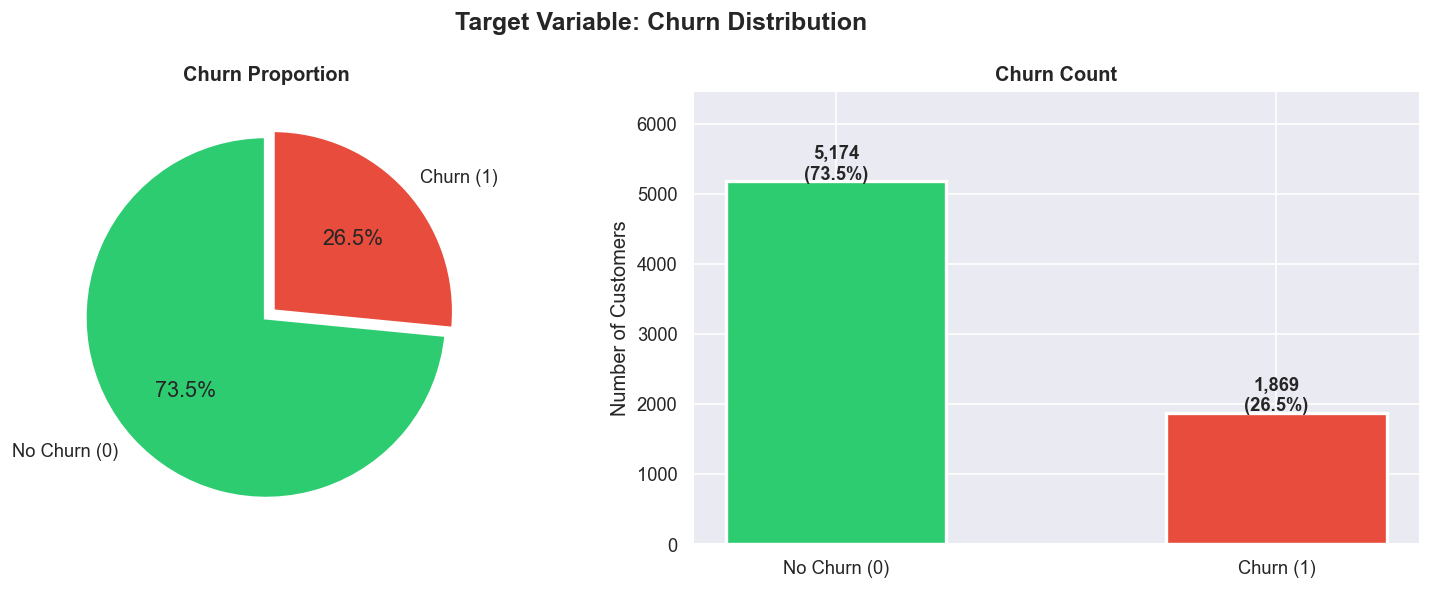

Imbalance ratio: 2.77:1  (No Churn : Churn)


In [11]:

# EDA 1 — Churn Distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Target Variable: Churn Distribution', fontsize=15, fontweight='bold')

churn_counts = df['Churn'].value_counts()
labels  = ['No Churn (0)', 'Churn (1)']
colors  = ['#2ECC71', '#E74C3C']
explode = [0, 0.05]

wedges, texts, autotexts = axes[0].pie(
    churn_counts, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90, explode=explode,
    wedgeprops=dict(edgecolor='white', linewidth=2.5)
)
for at in autotexts: at.set_fontsize(13)
axes[0].set_title('Churn Proportion', fontweight='bold')

bars = axes[1].bar(labels, churn_counts.values, color=colors,
                   edgecolor='white', linewidth=2, width=0.5)
for bar, val in zip(bars, churn_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Churn Count', fontweight='bold')
axes[1].set_ylabel('Number of Customers')
axes[1].set_ylim(0, churn_counts.max() * 1.25)

plt.tight_layout()
plt.savefig('plots/01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Imbalance ratio: {churn_counts[0]/churn_counts[1]:.2f}:1  (No Churn : Churn)')

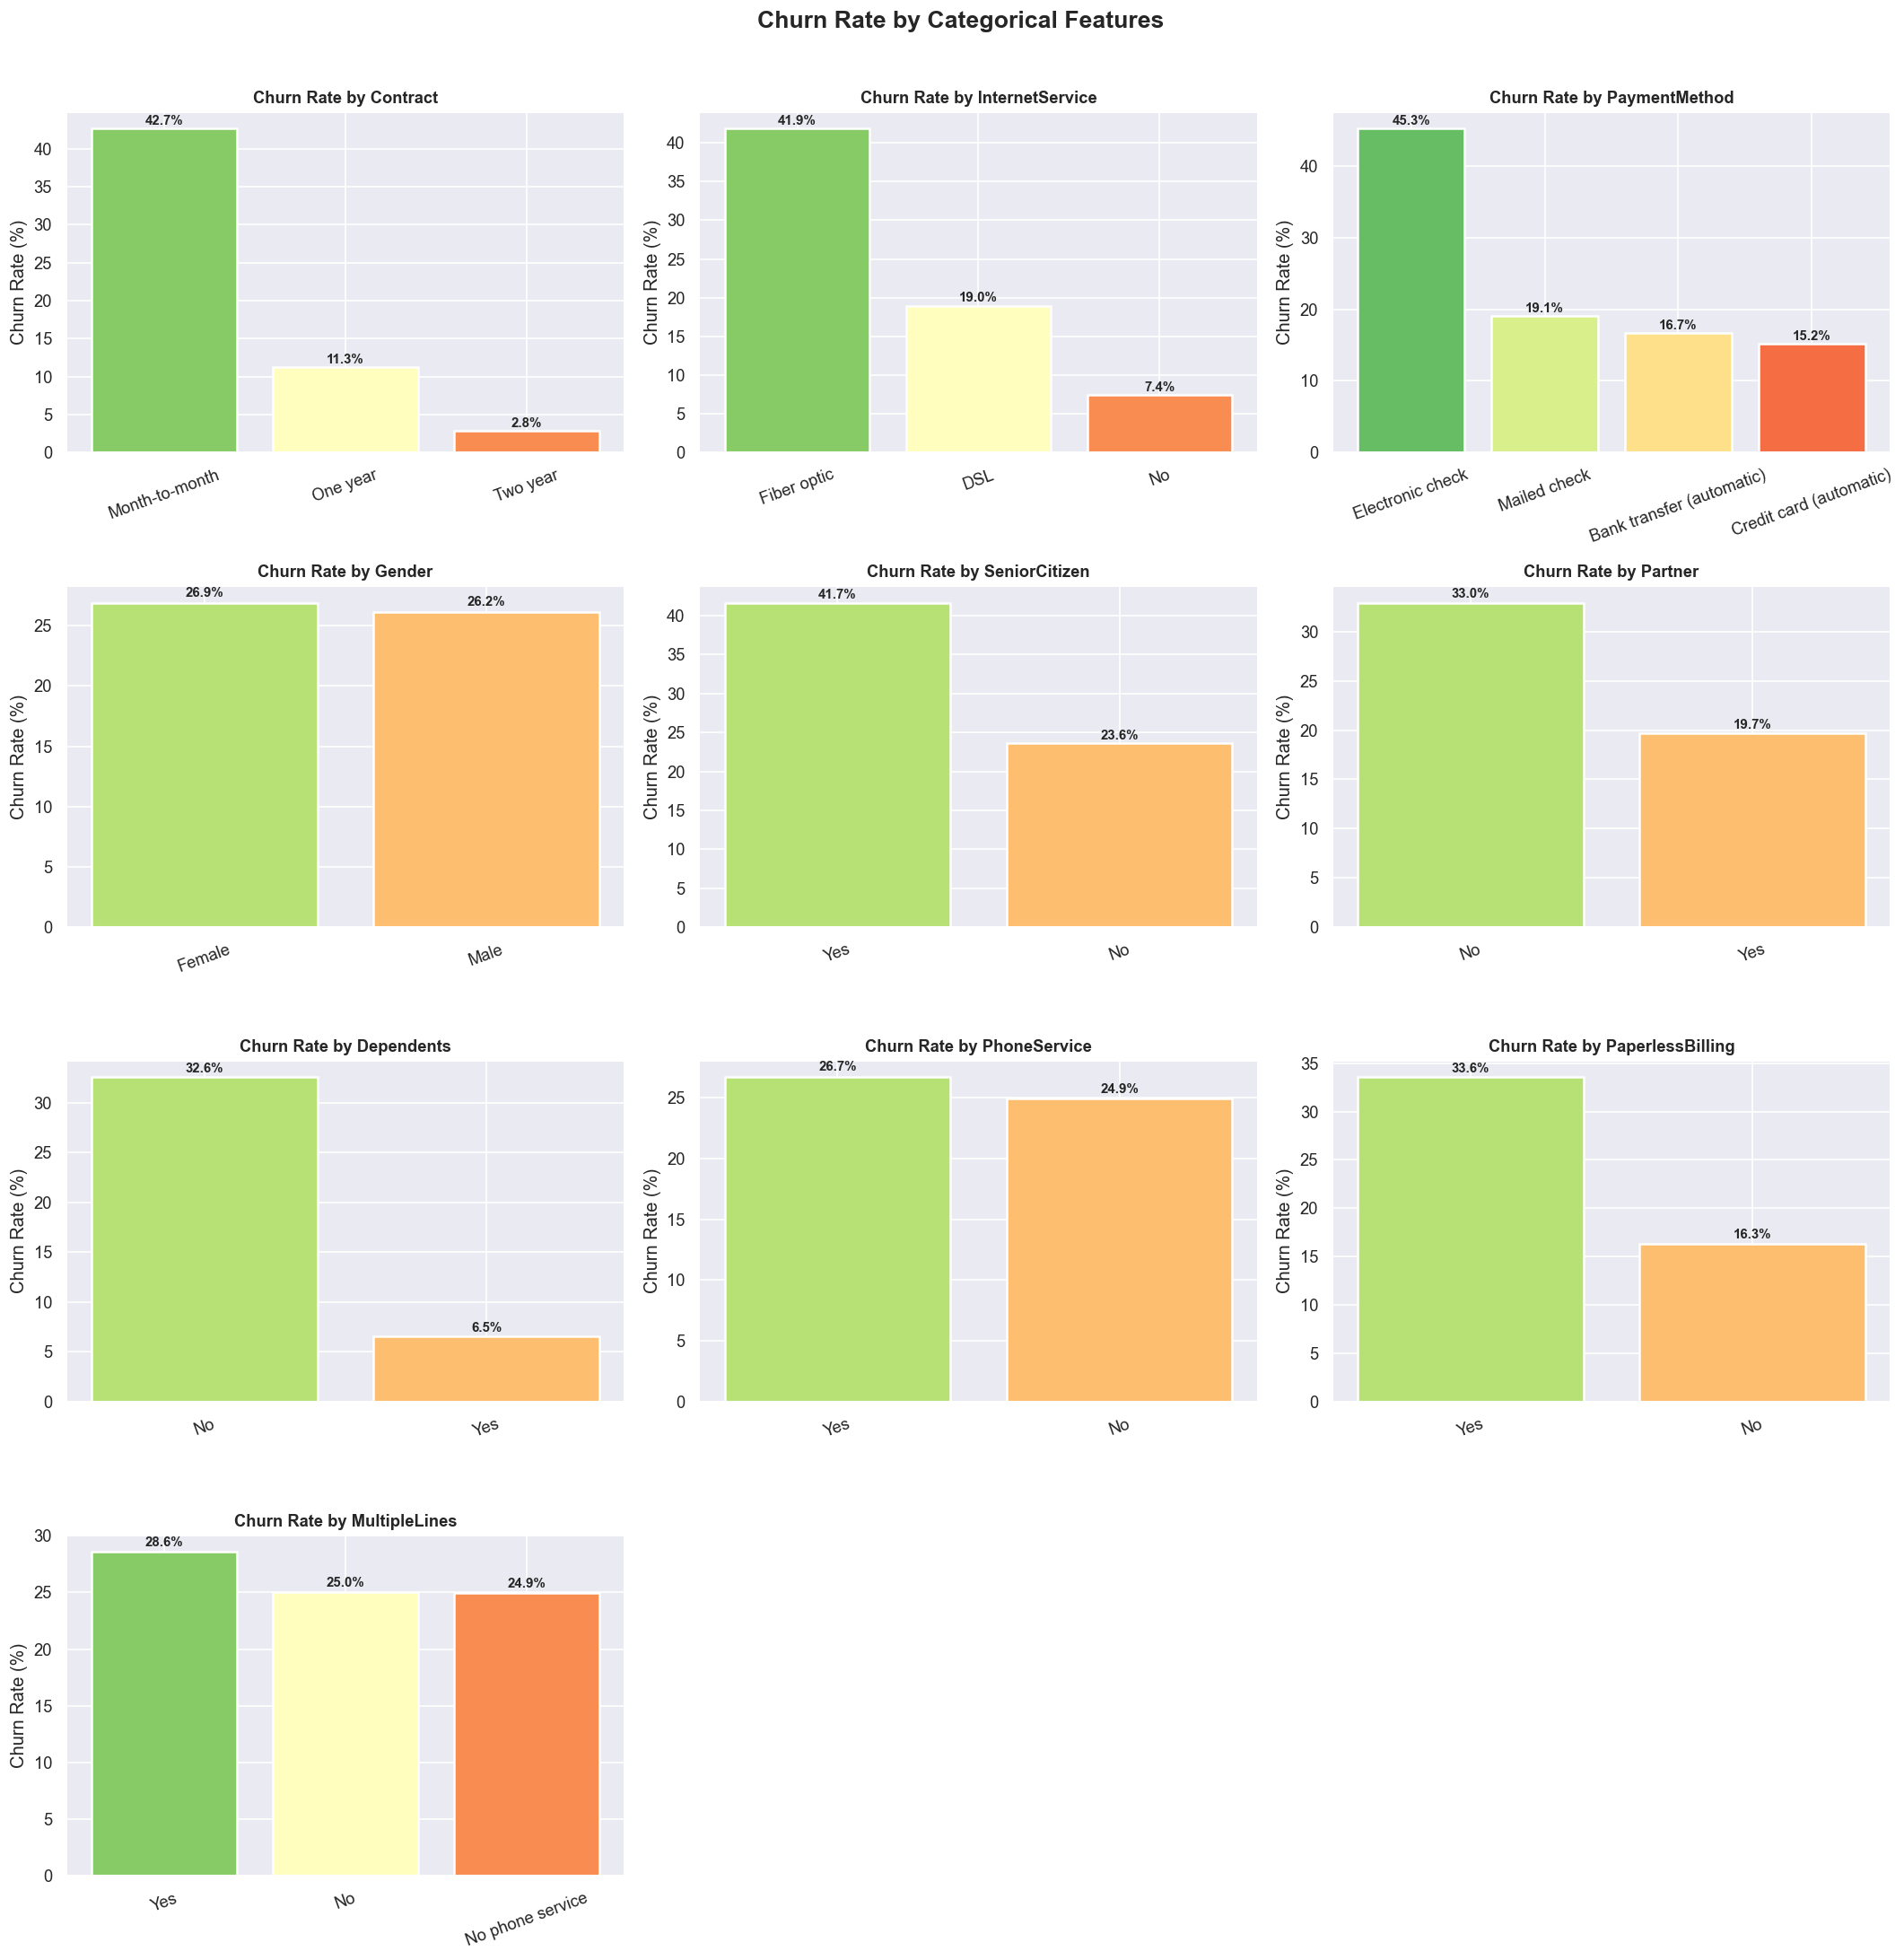

In [ ]:

cat_features_to_plot = [
    c for c in ['Contract', 'InternetService', 'PaymentMethod',
                'Gender', 'SeniorCitizen', 'Partner', 'Dependents',
                'PhoneService', 'PaperlessBilling', 'MultipleLines']
    if c in df.columns
]

ncols = 3
nrows = (len(cat_features_to_plot) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4.5))
fig.suptitle('Churn Rate by Categorical Features', fontsize=16, fontweight='bold', y=1.01)
axes = axes.flatten()

for i, col in enumerate(cat_features_to_plot):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    palette = sns.color_palette('RdYlGn_r', len(churn_rate))
    bars = axes[i].bar(churn_rate.index.astype(str), churn_rate.values * 100,
                       color=palette, edgecolor='white', linewidth=1.5)
    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, churn_rate.values * 100):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('plots/02_churn_by_categories.png', dpi=150, bbox_inches='tight')
plt.show()

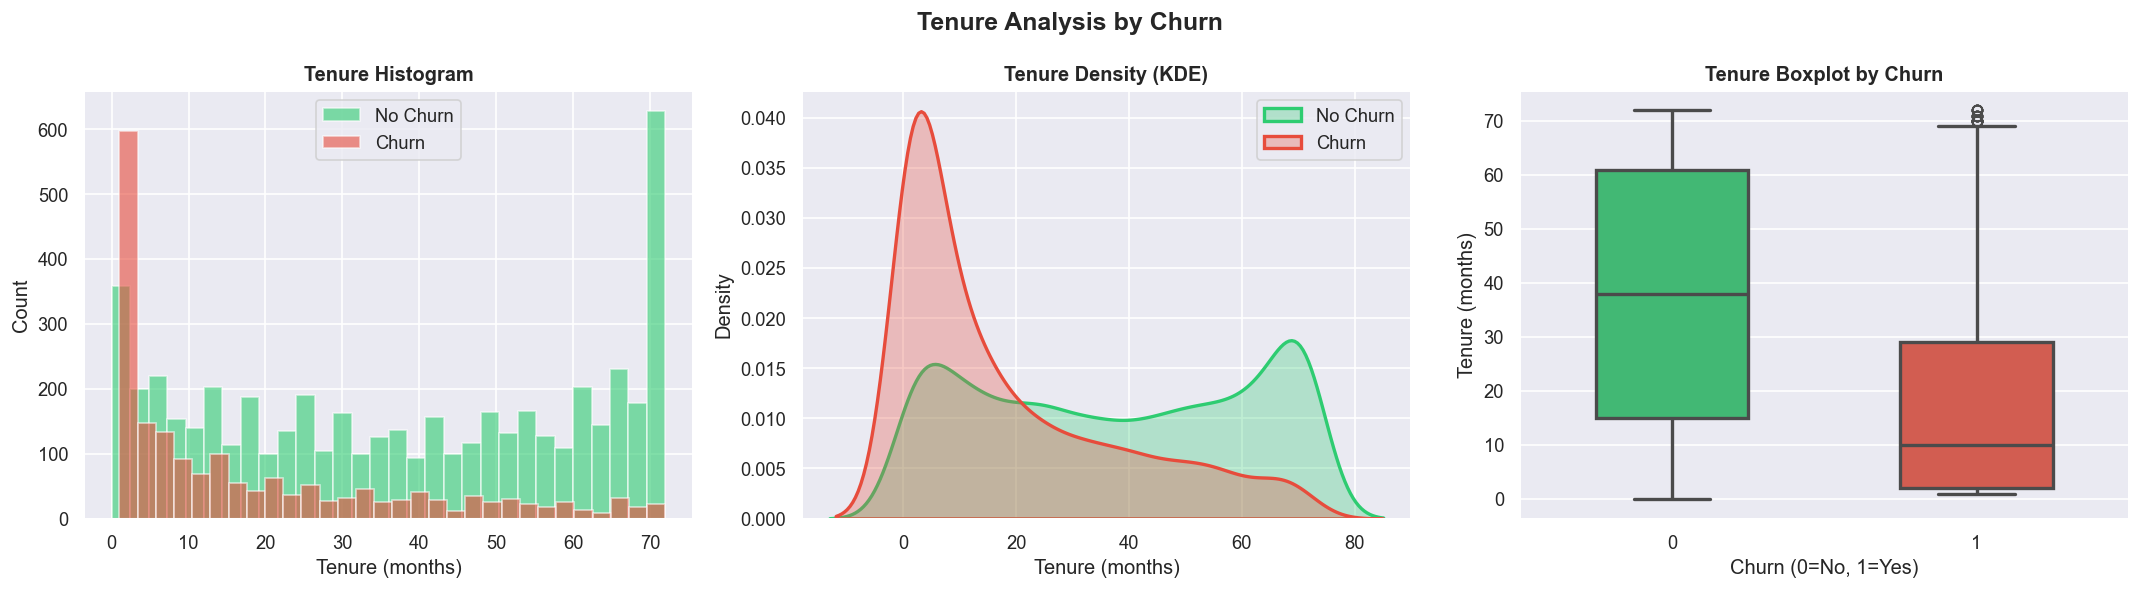

Average Tenure by Churn Status:
Churn
No Churn    37.6
Churn       18.0
Name: tenure, dtype: float64


In [13]:

# EDA 3 — Tenure Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Tenure Analysis by Churn', fontsize=15, fontweight='bold')

for cv, label, color in [(0, 'No Churn', '#2ECC71'), (1, 'Churn', '#E74C3C')]:
    axes[0].hist(df[df['Churn']==cv]['tenure'], bins=30,
                 alpha=0.6, color=color, label=label, edgecolor='white')
axes[0].set_title('Tenure Histogram', fontweight='bold')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Count')
axes[0].legend()


for cv, label, color in [(0, 'No Churn', '#2ECC71'), (1, 'Churn', '#E74C3C')]:
    sns.kdeplot(df[df['Churn']==cv]['tenure'], ax=axes[1],
                label=label, color=color, fill=True, alpha=0.3, linewidth=2)
axes[1].set_title('Tenure Density (KDE)', fontweight='bold')
axes[1].set_xlabel('Tenure (months)')
axes[1].legend()


sns.boxplot(data=df, x='Churn', y='tenure',
            palette=['#2ECC71', '#E74C3C'], ax=axes[2], width=0.5, linewidth=2)
axes[2].set_title('Tenure Boxplot by Churn', fontweight='bold')
axes[2].set_xlabel('Churn (0=No, 1=Yes)')
axes[2].set_ylabel('Tenure (months)')

plt.tight_layout()
plt.savefig('plots/03_tenure_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('Average Tenure by Churn Status:')
print(df.groupby('Churn')['tenure'].mean().rename({0:'No Churn', 1:'Churn'}).round(1))

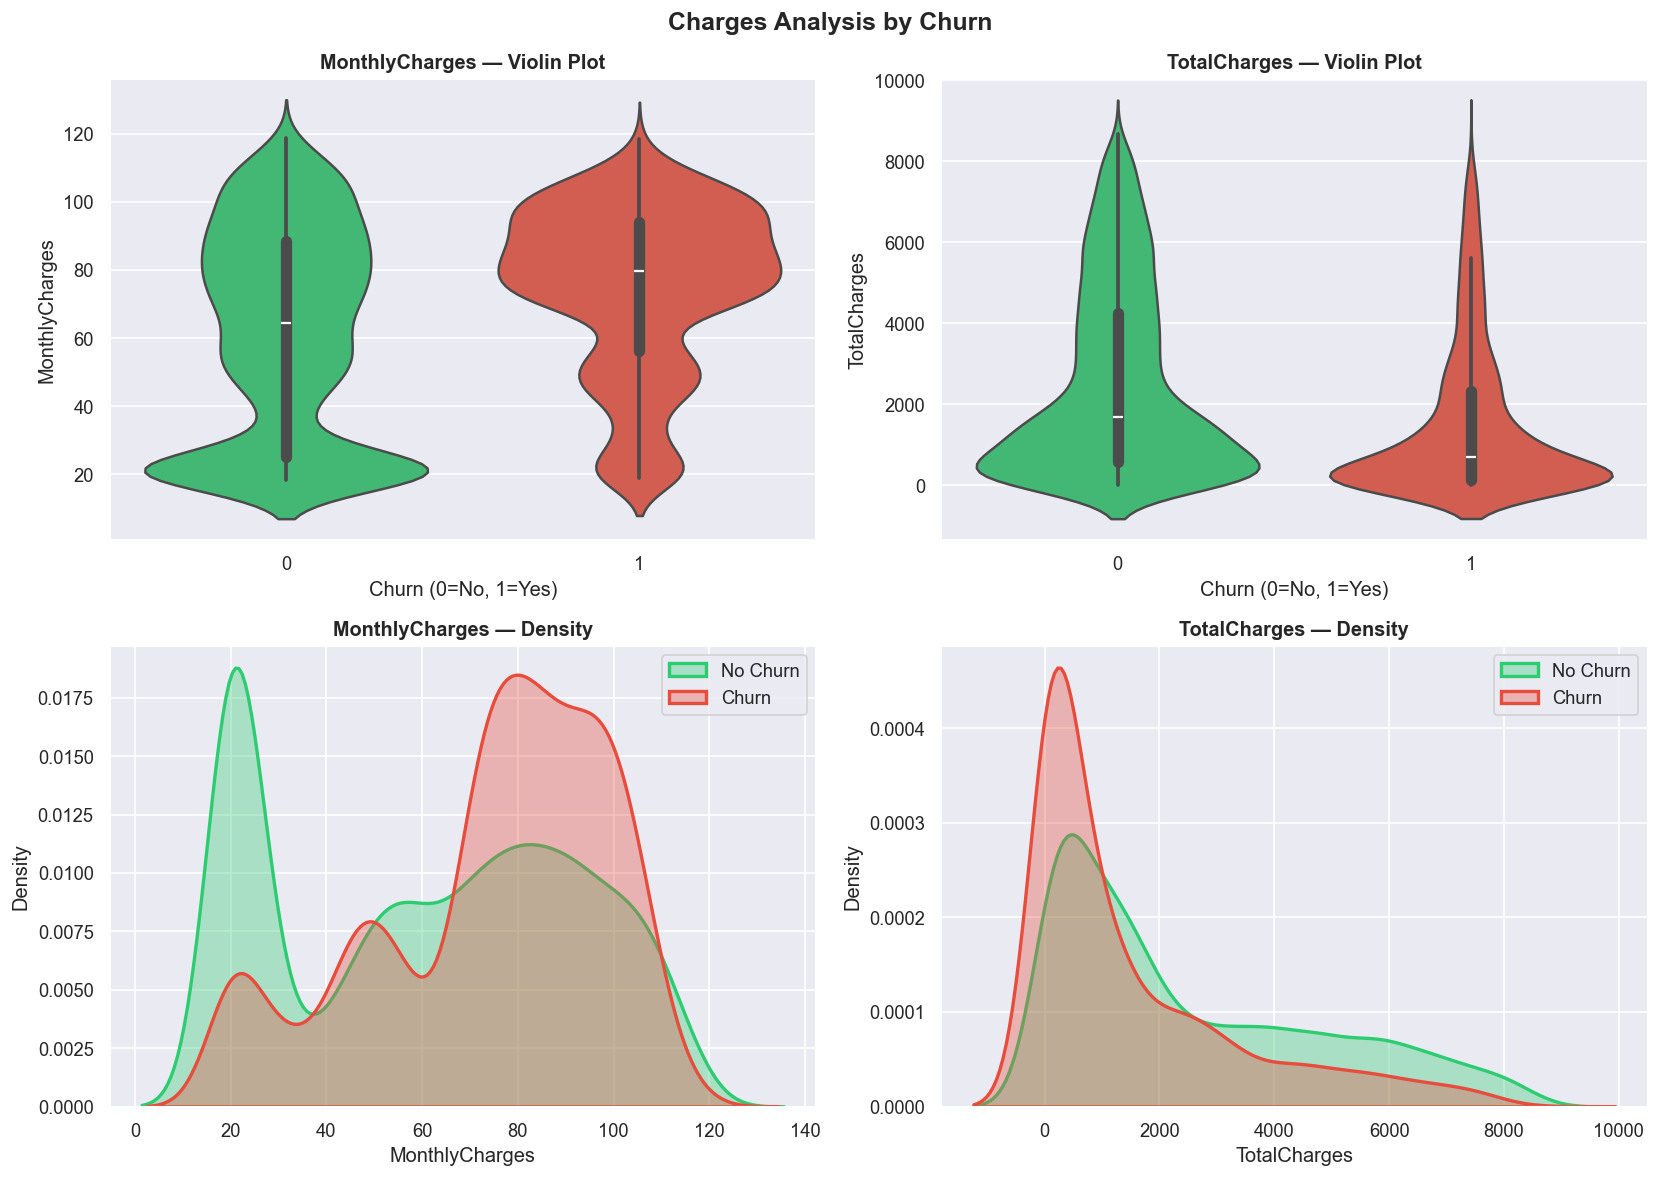

Average Charges by Churn Status:
       MonthlyCharges  TotalCharges
Churn                              
0               61.27       2552.88
1               74.44       1531.80


In [14]:

# EDA 4 — Monthly & Total Charges Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Charges Analysis by Churn', fontsize=15, fontweight='bold')

for col_idx, col in enumerate(['MonthlyCharges', 'TotalCharges']):

    sns.violinplot(data=df, x='Churn', y=col, palette=['#2ECC71','#E74C3C'],
                   ax=axes[0][col_idx], inner='box', linewidth=1.5)
    axes[0][col_idx].set_title(f'{col} — Violin Plot', fontweight='bold')
    axes[0][col_idx].set_xlabel('Churn (0=No, 1=Yes)')

    for cv, label, color in [(0,'No Churn','#2ECC71'), (1,'Churn','#E74C3C')]:
        sns.kdeplot(df[df['Churn']==cv][col], ax=axes[1][col_idx],
                    label=label, color=color, fill=True, alpha=0.35, linewidth=2)
    axes[1][col_idx].set_title(f'{col} — Density', fontweight='bold')
    axes[1][col_idx].set_xlabel(col)
    axes[1][col_idx].legend()

plt.tight_layout()
plt.savefig('plots/04_charges_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('Average Charges by Churn Status:')
print(df.groupby('Churn')[['MonthlyCharges','TotalCharges']].mean().round(2))

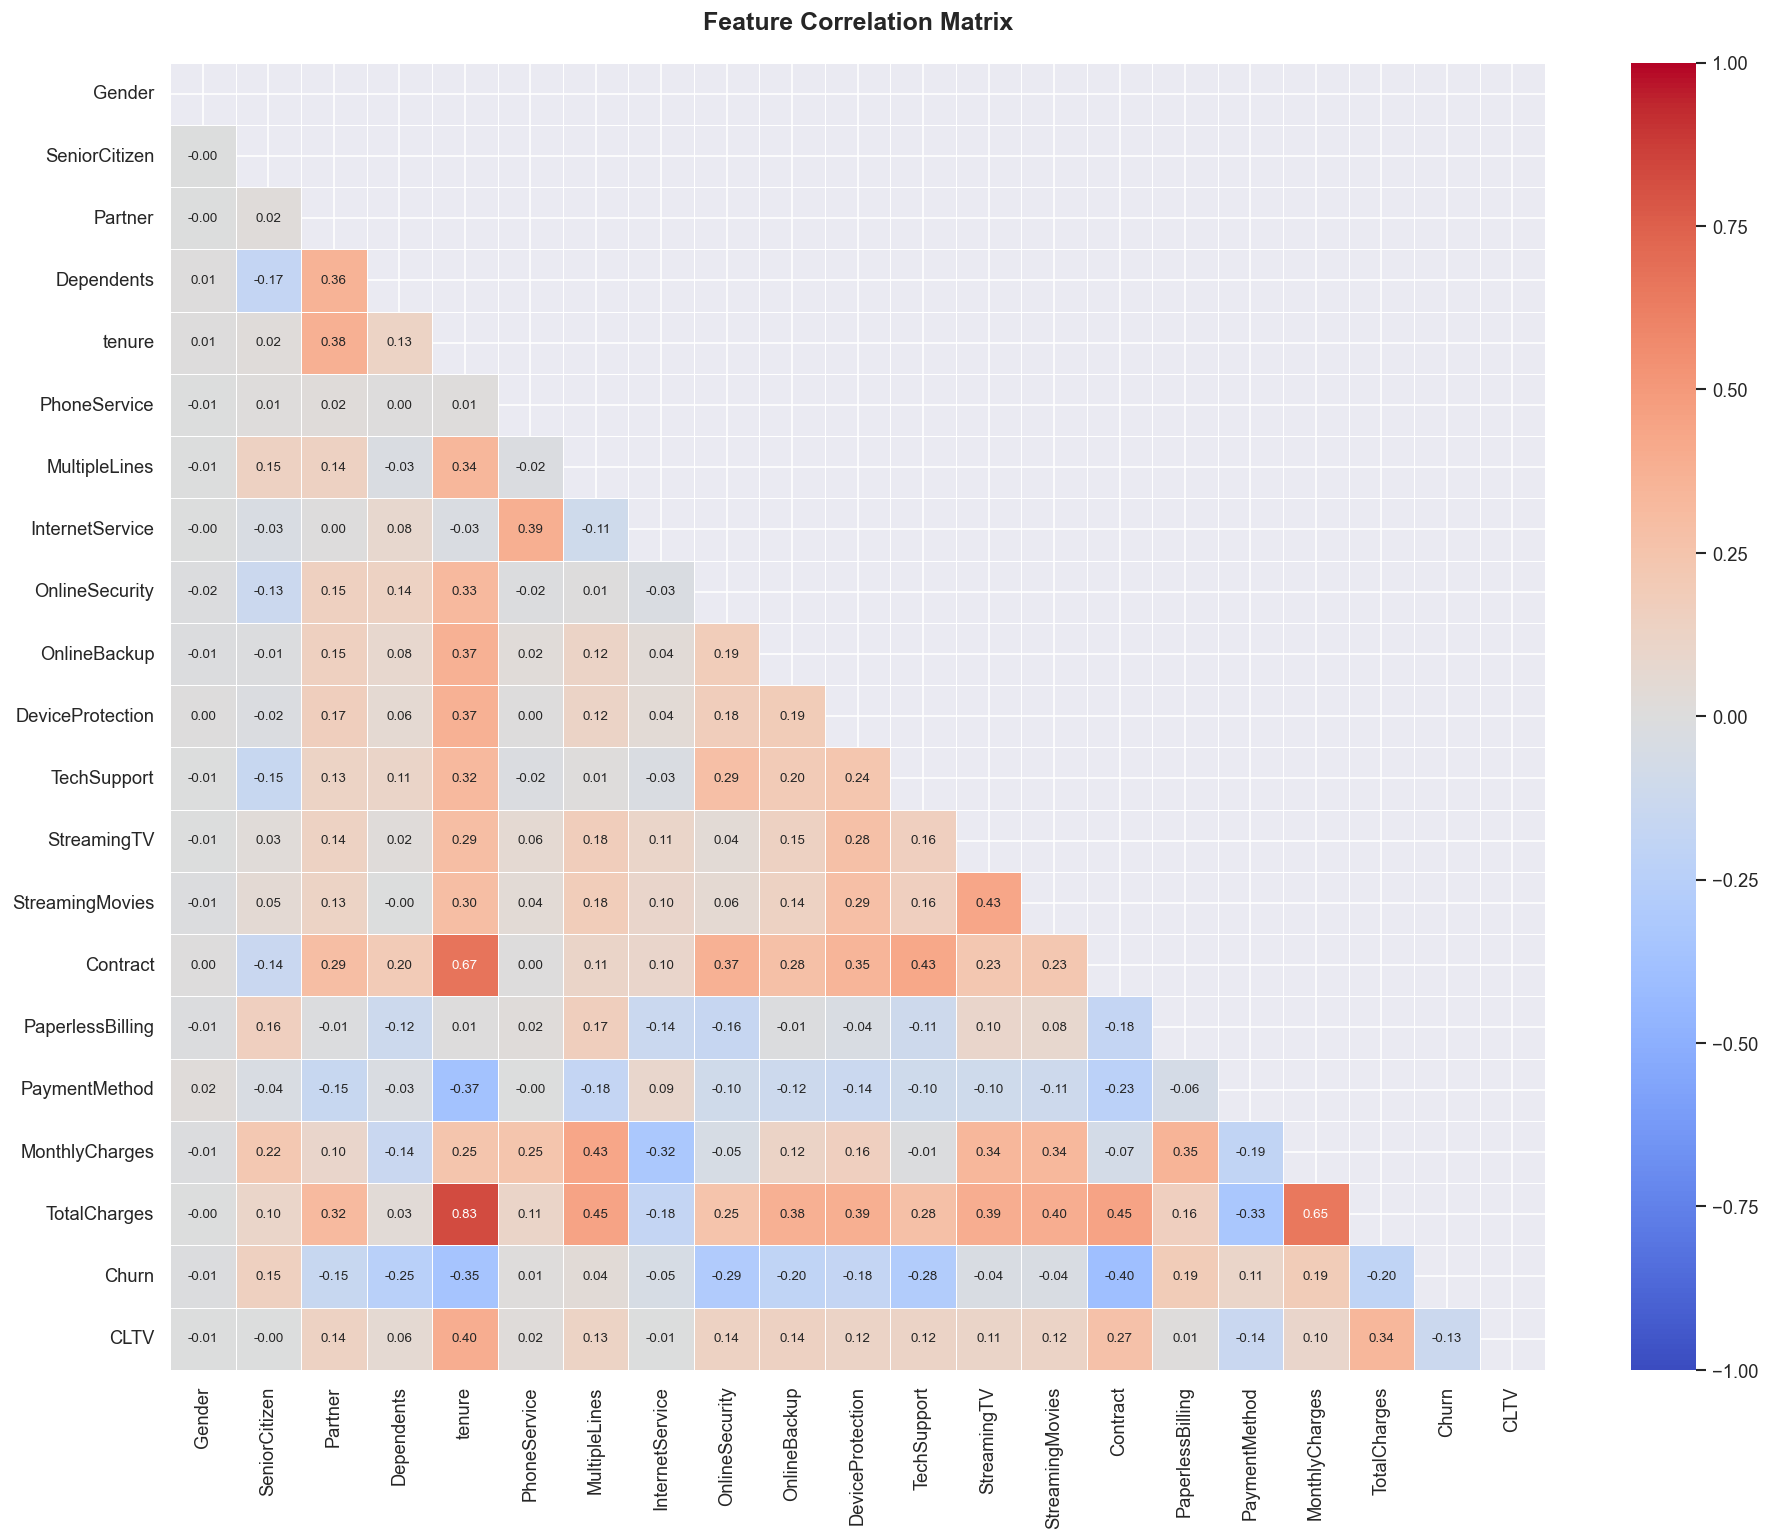


Top Features Correlated with Churn:
Contract            0.396713
tenure              0.352229
OnlineSecurity      0.289309
TechSupport         0.282492
Dependents          0.248542
TotalCharges        0.199037
OnlineBackup        0.195525
MonthlyCharges      0.193356
PaperlessBilling    0.191825
DeviceProtection    0.178134
Name: Churn, dtype: float64


In [15]:

# EDA 5 — Correlation Heatmap
df_enc = df.copy()
for c in df_enc.select_dtypes(include='object').columns:
    df_enc[c] = LabelEncoder().fit_transform(df_enc[c].astype(str))

fig, ax = plt.subplots(figsize=(16, 13))
corr = df_enc.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, ax=ax, annot_kws={'size': 8}, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('plots/05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop Features Correlated with Churn:')
print(corr['Churn'].drop('Churn').abs().sort_values(ascending=False).head(10))

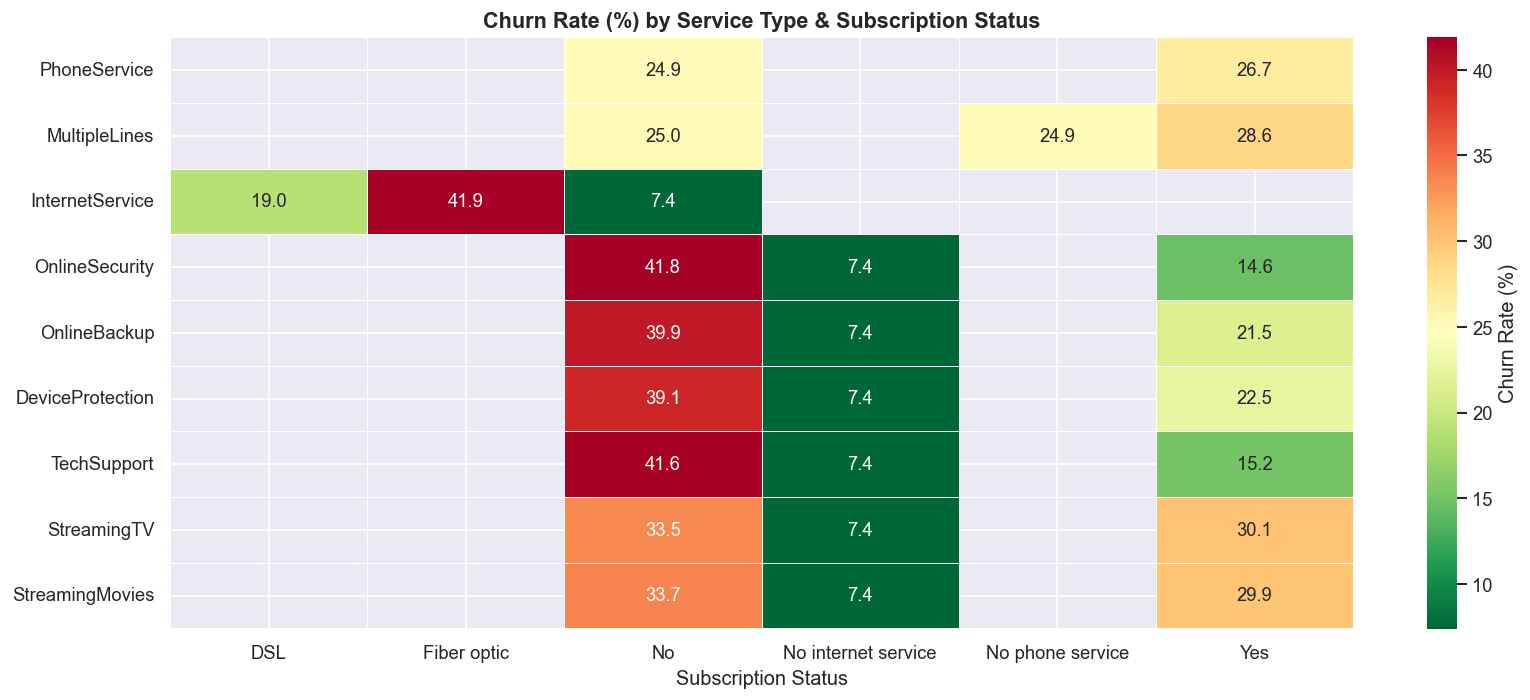

In [16]:

# EDA 6 — Services vs Churn Heatmap
service_cols = [c for c in ['PhoneService','MultipleLines','InternetService',
                             'OnlineSecurity','OnlineBackup','DeviceProtection',
                             'TechSupport','StreamingTV','StreamingMovies'] if c in df.columns]

fig, ax = plt.subplots(figsize=(14, 6))
svc_data = {}
for col in service_cols:
    svc_data[col] = df.groupby(col)['Churn'].mean() * 100
svc_df = pd.DataFrame(svc_data).T

sns.heatmap(svc_df, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, annot_kws={'size': 11},
            cbar_kws={'label': 'Churn Rate (%)'})
ax.set_title('Churn Rate (%) by Service Type & Subscription Status',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Subscription Status')
plt.tight_layout()
plt.savefig('plots/06_services_churn_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

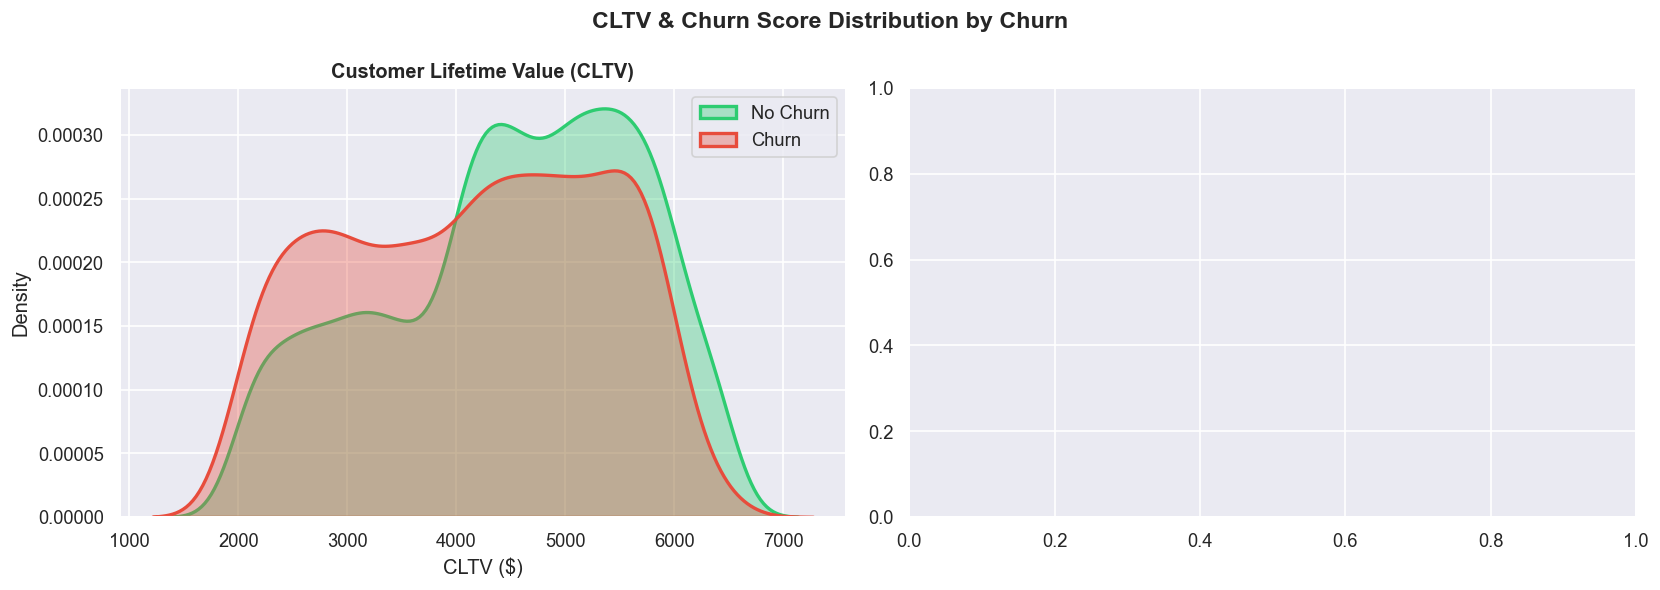

In [17]:

# EDA 7 — CLTV & Churn Score Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CLTV & Churn Score Distribution by Churn', fontsize=14, fontweight='bold')

for cv, label, color in [(0,'No Churn','#2ECC71'), (1,'Churn','#E74C3C')]:
    subset = df[df['Churn']==cv]
    if 'CLTV' in df.columns:
        sns.kdeplot(subset['CLTV'], ax=axes[0], label=label,
                    color=color, fill=True, alpha=0.35, linewidth=2)

axes[0].set_title('Customer Lifetime Value (CLTV)', fontweight='bold')
axes[0].set_xlabel('CLTV ($)')
axes[0].legend()

if 'Churn_Score' in df_raw.columns:
    df_raw['Churn'] = df_raw['Churn Value'].values
    for cv, label, color in [(0,'No Churn','#2ECC71'), (1,'Churn','#E74C3C')]:
        subset = df_raw[df_raw['Churn']==cv]
        axes[1].hist(subset['Churn Score'], bins=25, alpha=0.6,
                     color=color, label=label, edgecolor='white')
    axes[1].set_title('Churn Score Distribution', fontweight='bold')
    axes[1].set_xlabel('Churn Score (0-100)')
    axes[1].set_ylabel('Count')
    axes[1].legend()

plt.tight_layout()
plt.savefig('plots/07_cltv_score.png', dpi=150, bbox_inches='tight')
plt.show()

---
 :-Feature Engineering

Creating new features to help the model capture hidden patterns:

| New Feature | Description |
|-------------|-------------|
| `tenure_group` | Binned tenure into 6 groups |
| `avg_monthly_spend` | TotalCharges / (tenure + 1) |
| `service_count` | Number of add-on services subscribed |
| `has_phone_internet` | 1 if customer has both phone and internet |
| `charge_per_service` | MonthlyCharges / (service_count + 1) |

In [18]:
df_fe = df.copy()

df_fe['tenure_group'] = pd.cut(df_fe['tenure'],
    bins=[0, 12, 24, 36, 48, 60, 200],
    labels=['0-12', '13-24', '25-36', '37-48', '49-60', '61+'])
print('[OK] tenure_group created')

df_fe['avg_monthly_spend'] = df_fe['TotalCharges'] / (df_fe['tenure'] + 1)
print('[OK] avg_monthly_spend created')


addon_svc = ['OnlineSecurity','OnlineBackup','DeviceProtection',
             'TechSupport','StreamingTV','StreamingMovies']
existing_svc = [c for c in addon_svc if c in df_fe.columns]
for c in existing_svc:
    df_fe[c + '_bin'] = (df_fe[c].str.lower() == 'yes').astype(int)
df_fe['service_count'] = df_fe[[c + '_bin' for c in existing_svc]].sum(axis=1)
df_fe.drop(columns=[c + '_bin' for c in existing_svc], inplace=True)
print(f'[OK] service_count created (from {len(existing_svc)} services)')


if 'PhoneService' in df_fe.columns and 'InternetService' in df_fe.columns:
    df_fe['has_phone_internet'] = (
        (df_fe['PhoneService'].str.lower() == 'yes') &
        (df_fe['InternetService'].str.lower() != 'no')
    ).astype(int)
    print('[OK] has_phone_internet created')


df_fe['charge_per_service'] = df_fe['MonthlyCharges'] / (df_fe['service_count'] + 1)
print('[OK] charge_per_service created')

print(f'\nTotal features after engineering: {df_fe.shape[1]}')
df_fe.head(3)

[OK] tenure_group created
[OK] avg_monthly_spend created
[OK] service_count created (from 6 services)
[OK] has_phone_internet created
[OK] charge_per_service created

Total features after engineering: 26


,Gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,CLTV,tenure_group,avg_monthly_spend,service_count,has_phone_internet,charge_per_service
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,Mailed check,53.85,108.15,1,3239,0-12,36.050000,2,1,17.9500
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,Electronic check,70.70,151.65,1,2701,0-12,50.550000,0,1,70.7000
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,Electronic check,99.65,820.50,1,5372,0-12,91.166667,3,1,24.9125


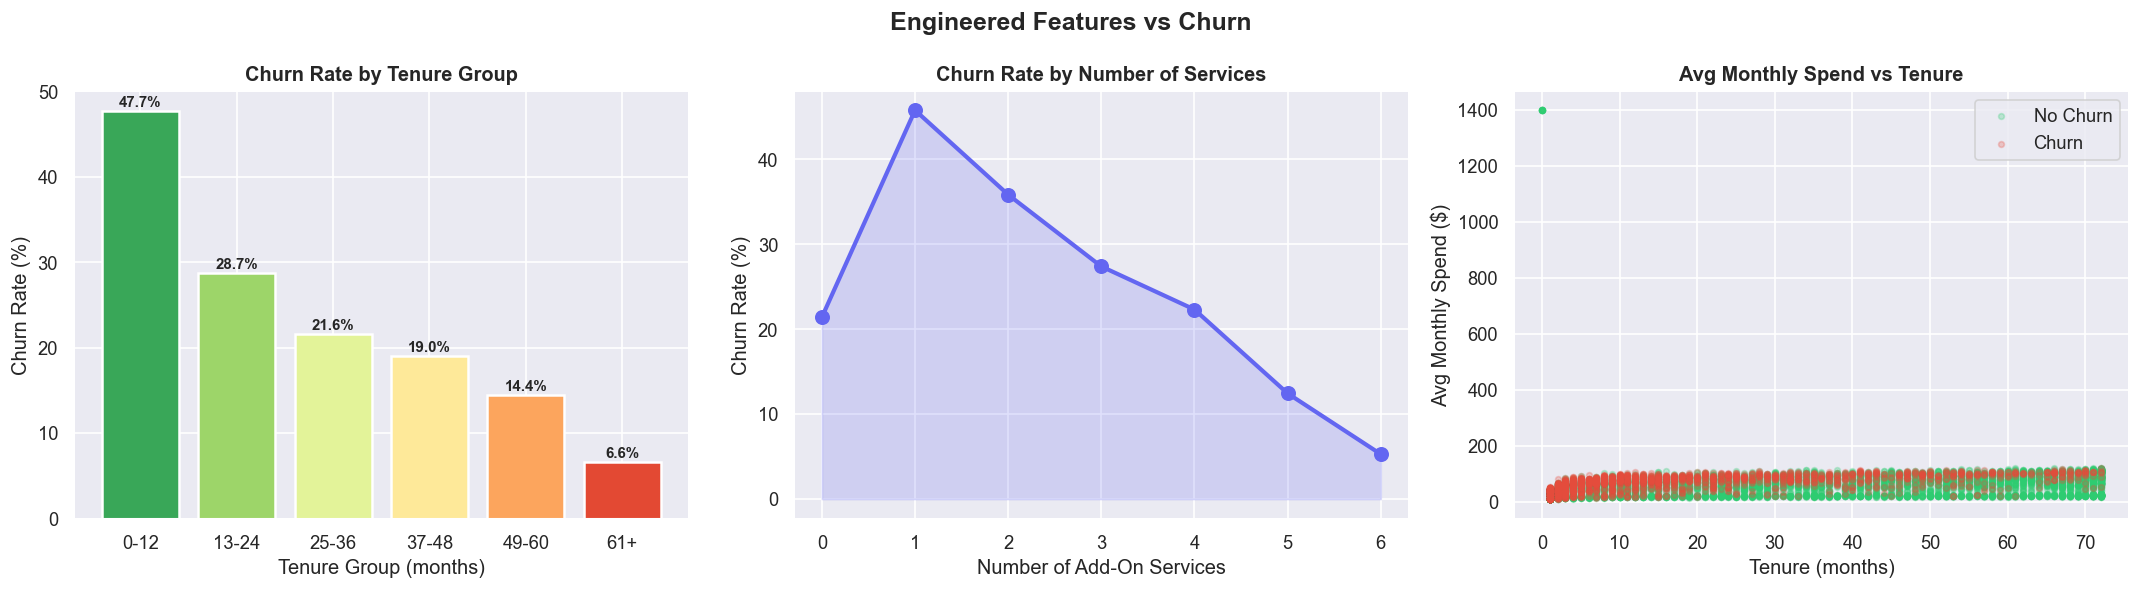

In [19]:


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Engineered Features vs Churn', fontsize=15, fontweight='bold')

tg = df_fe.groupby('tenure_group', observed=True)['Churn'].mean() * 100
palette_tg = sns.color_palette('RdYlGn_r', len(tg))
bars = axes[0].bar(tg.index.astype(str), tg.values, color=palette_tg,
                   edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, tg.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Churn Rate by Tenure Group', fontweight='bold')
axes[0].set_xlabel('Tenure Group (months)')
axes[0].set_ylabel('Churn Rate (%)')

sc = df_fe.groupby('service_count')['Churn'].mean() * 100
axes[1].plot(sc.index, sc.values, 'o-', color='#6366f1', linewidth=2.5, markersize=8)
axes[1].fill_between(sc.index, sc.values, alpha=0.2, color='#6366f1')
axes[1].set_title('Churn Rate by Number of Services', fontweight='bold')
axes[1].set_xlabel('Number of Add-On Services')
axes[1].set_ylabel('Churn Rate (%)')

for cv, color, label in [(0,'#2ECC71','No Churn'), (1,'#E74C3C','Churn')]:
    sub = df_fe[df_fe['Churn']==cv]
    axes[2].scatter(sub['tenure'], sub['avg_monthly_spend'],
                    alpha=0.25, color=color, label=label, s=12)
axes[2].set_title('Avg Monthly Spend vs Tenure', fontweight='bold')
axes[2].set_xlabel('Tenure (months)')
axes[2].set_ylabel('Avg Monthly Spend ($)')
axes[2].legend()

plt.tight_layout()
plt.savefig('plots/08_engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()

---
: Split the Data

In [20]:

X = df_fe.drop(columns=['Churn'])
y = df_fe['Churn'].astype(int)

cat_feats = X.select_dtypes(include=['object', 'category']).columns.tolist()
for c in cat_feats:
    X[c] = LabelEncoder().fit_transform(X[c].astype(str))

print(f'Feature matrix : {X.shape}')
print(f'Target vector  : {y.shape}')
print(f'\nAll features ({X.shape[1]}):')
print(list(X.columns))

Feature matrix : (7043, 25)
Target vector  : (7043,)

All features (25):
['Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'CLTV', 'tenure_group', 'avg_monthly_spend', 'service_count', 'has_phone_internet', 'charge_per_service']


In [21]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)

print('Before SMOTE:')
print(f'  Train : {X_train_sc.shape[0]:,} | Churn rate: {y_train.mean()*100:.1f}%')
print(f'  Test  : {X_test_sc.shape[0]:,}  | Churn rate: {y_test.mean()*100:.1f}%')
print('\nAfter SMOTE (training only):')
vals, cnts = np.unique(y_train_sm, return_counts=True)
for v, c in zip(vals, cnts):
    print(f'  Class {v}: {c:,} samples')

Before SMOTE:
  Train : 5,634 | Churn rate: 26.5%
  Test  : 1,409  | Churn rate: 26.5%

After SMOTE (training only):
  Class 0: 4,139 samples
  Class 1: 4,139 samples


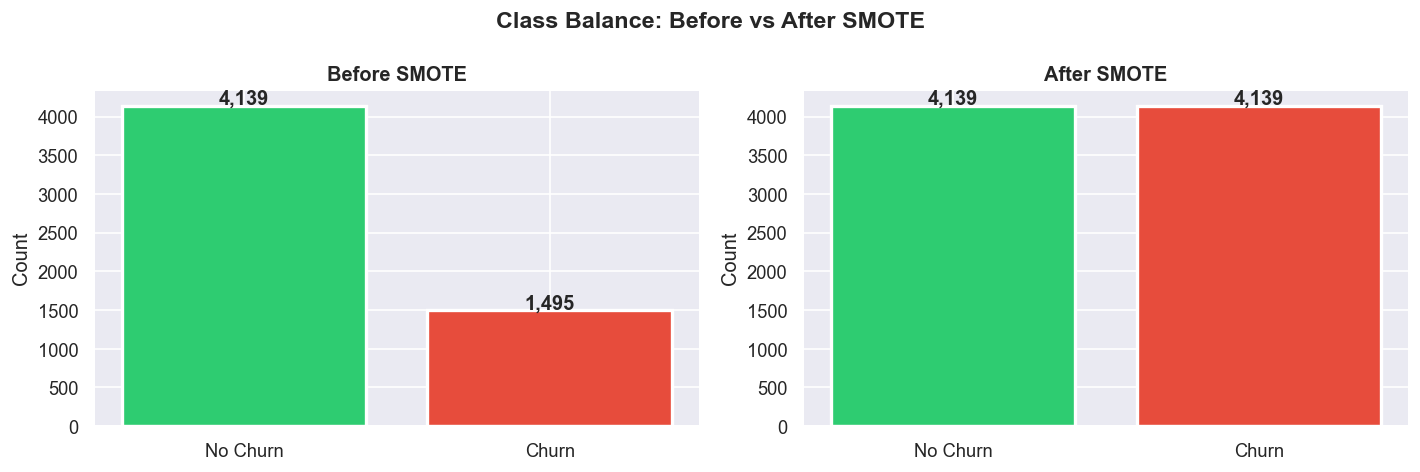

In [22]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Class Balance: Before vs After SMOTE', fontsize=14, fontweight='bold')

before = pd.Series(y_train).value_counts()
after  = pd.Series(y_train_sm).value_counts()

for ax, data, title in [(axes[0], before, 'Before SMOTE'),
                         (axes[1], after,  'After SMOTE')]:
    bars = ax.bar(['No Churn', 'Churn'], [data[0], data[1]],
                  color=['#2ECC71','#E74C3C'], edgecolor='white', linewidth=2)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    for bar, val in zip(bars, [data[0], data[1]]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                f'{val:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('plots/09_smote_balance.png', dpi=150, bbox_inches='tight')
plt.show()

---
: Choose and Train Models

| Model | Strength |
|-------|----------|
| **Logistic Regression** | Fast linear baseline, interpretable |
| **Random Forest** | Handles non-linearity, robust to noise |
| **XGBoost** | State-of-the-art gradient boosting |
| **SVM** | Effective in high-dimensional spaces |

In [23]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=200, random_state=42,
                                         use_label_encoder=False, eval_metric='logloss',
                                         n_jobs=-1, verbosity=0),
    'SVM':                 SVC(kernel='rbf', probability=True, random_state=42)
}

results = {}
print('Training models...\n')

for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    y_pred  = model.predict(X_test_sc)
    y_proba = model.predict_proba(X_test_sc)[:, 1]
    results[name] = {
        'model':     model,
        'y_pred':    y_pred,
        'y_proba':   y_proba,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1-Score':  f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_proba),
    }
    print(f'[{name}]  Acc={results[name]["Accuracy"]:.4f}  '
          f'Prec={results[name]["Precision"]:.4f}  '
          f'Rec={results[name]["Recall"]:.4f}  '
          f'F1={results[name]["F1-Score"]:.4f}  '
          f'AUC={results[name]["ROC-AUC"]:.4f}')

print('\nAll models trained!')

Training models...

[Logistic Regression]  Acc=0.7495  Prec=0.5187  Rec=0.7781  F1=0.6225  AUC=0.8520
[Random Forest]  Acc=0.7807  Prec=0.5835  Rec=0.6070  F1=0.5950  AUC=0.8395
[XGBoost]  Acc=0.7779  Prec=0.5831  Rec=0.5722  F1=0.5776  AUC=0.8269
[SVM]  Acc=0.7644  Prec=0.5422  Rec=0.7219  F1=0.6193  AUC=0.8325

All models trained!


---
: Evaluate the Model

In [24]:

metrics_df = pd.DataFrame({
    name: {'Accuracy': res['Accuracy'], 'Precision': res['Precision'],
           'Recall': res['Recall'], 'F1-Score': res['F1-Score'], 'ROC-AUC': res['ROC-AUC']}
    for name, res in results.items()
}).T.round(4)

display(metrics_df.style
    .background_gradient(cmap='RdYlGn', axis=0)
    .format('{:.4f}')
    .set_caption('All metrics evaluated on TEST set (20% hold-out)'))

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.7495,0.5187,0.7781,0.6225,0.8520
Random Forest,0.7807,0.5835,0.6070,0.5950,0.8395
XGBoost,0.7779,0.5831,0.5722,0.5776,0.8269
SVM,0.7644,0.5422,0.7219,0.6193,0.8325


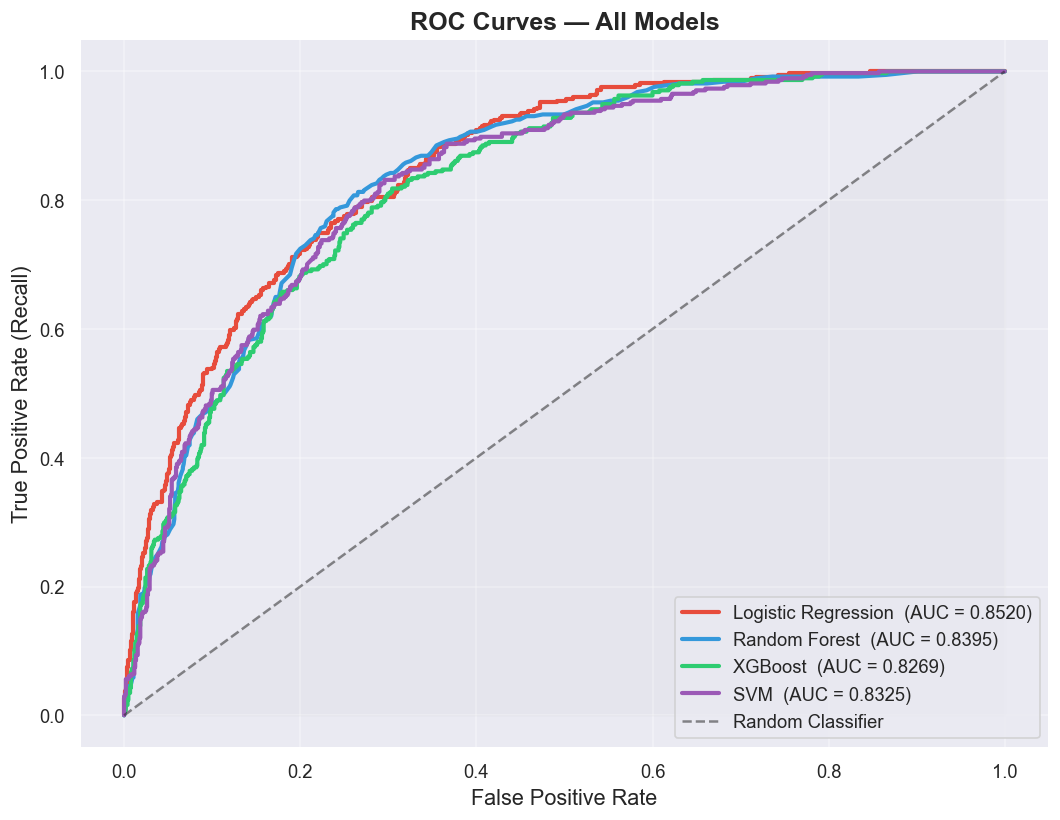

In [25]:

fig, ax = plt.subplots(figsize=(9, 7))
colors_roc = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']

for (name, res), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax.plot(fpr, tpr, color=color, lw=2.5,
            label=f"{name}  (AUC = {res['ROC-AUC']:.4f})")

ax.plot([0,1],[0,1], 'k--', lw=1.5, alpha=0.5, label='Random Classifier')
ax.fill_between([0,1],[0,1], alpha=0.04, color='gray')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=13)
ax.set_title('ROC Curves — All Models', fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('plots/10_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

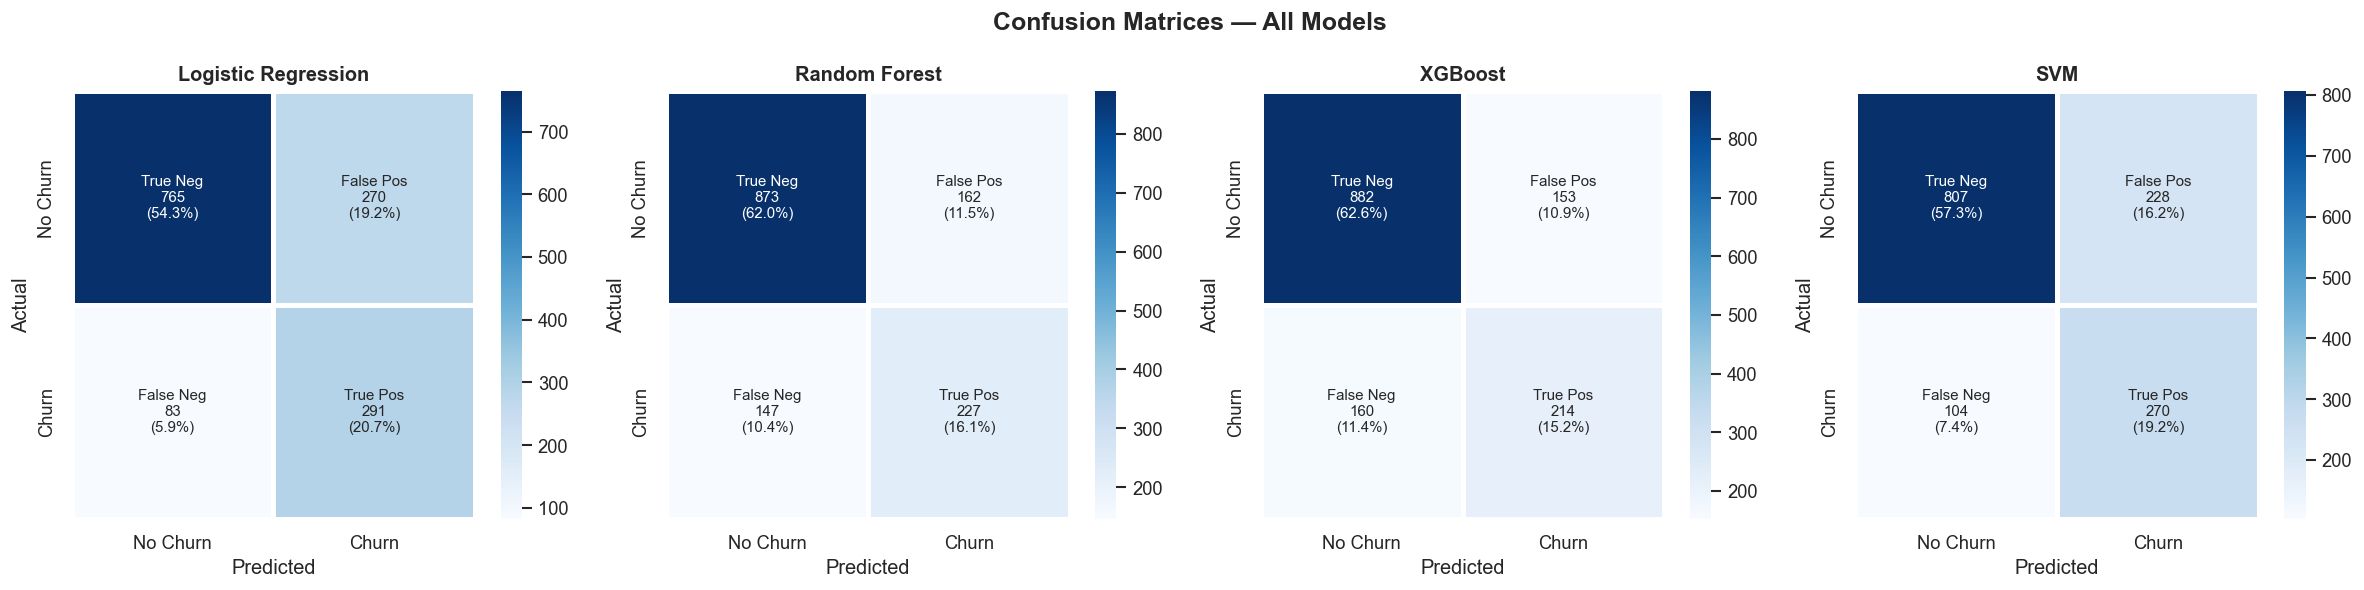

In [26]:


fig, axes = plt.subplots(1, len(results), figsize=(20, 5))
fig.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold')

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    group_names  = ['True Neg','False Pos','False Neg','True Pos']
    group_counts = [f'{v:,}' for v in cm.flatten()]
    group_pct    = [f'{v:.1%}' for v in cm.flatten()/np.sum(cm)]
    annot_labels = np.array([f'{n}\n{c}\n({p})' for n, c, p in
                              zip(group_names, group_counts, group_pct)]).reshape(2, 2)

    sns.heatmap(cm, annot=annot_labels, fmt='', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'],
                linewidths=2, linecolor='white', annot_kws={'size': 9})
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('plots/11_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

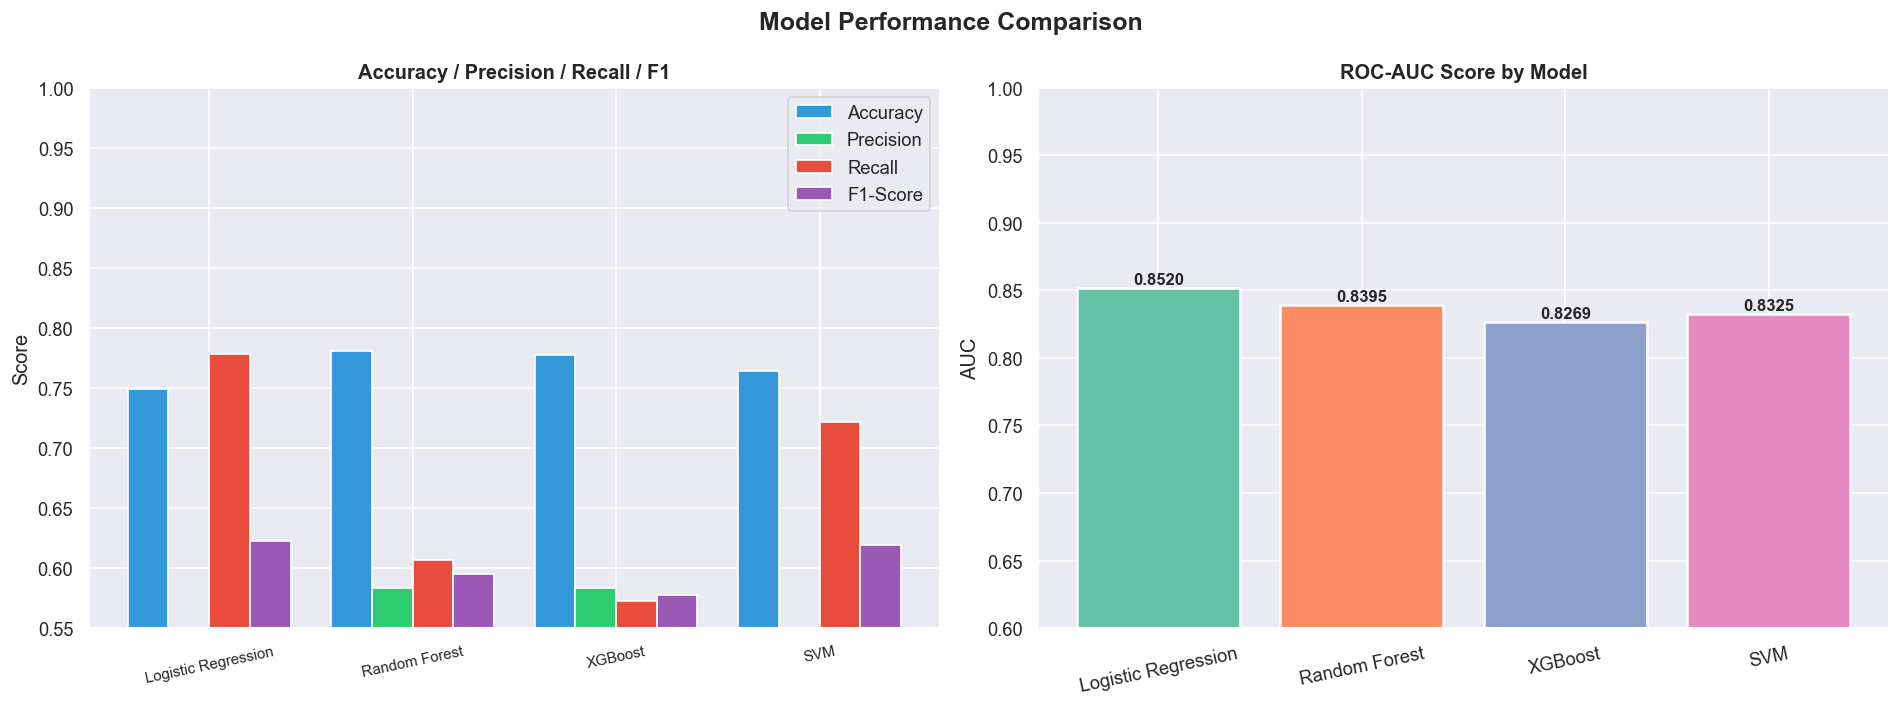

In [27]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')

x = np.arange(len(results))
names  = list(results.keys())
width  = 0.2
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
palette = ['#3498DB', '#2ECC71', '#E74C3C', '#9B59B6']

for i, (metric, color) in enumerate(zip(metric_cols, palette)):
    vals = [results[n][metric] for n in names]
    axes[0].bar(x + i*width, vals, width, label=metric, color=color, edgecolor='white')

axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(names, rotation=12, fontsize=9)
axes[0].set_ylim(0.55, 1.0)
axes[0].set_title('Accuracy / Precision / Recall / F1', fontweight='bold')
axes[0].legend()
axes[0].set_ylabel('Score')

roc_vals = [results[n]['ROC-AUC'] for n in names]
colors_bar = sns.color_palette('Set2', len(names))
bars = axes[1].bar(names, roc_vals, color=colors_bar, edgecolor='white', linewidth=1.5)
axes[1].set_ylim(0.6, 1.0)
axes[1].set_title('ROC-AUC Score by Model', fontweight='bold')
axes[1].set_ylabel('AUC')
axes[1].tick_params(axis='x', rotation=12)
for bar, val in zip(bars, roc_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{val:.4f}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('plots/12_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Best Model (by ROC-AUC): Logistic Regression

              precision    recall  f1-score   support

    No Churn       0.90      0.74      0.81      1035
       Churn       0.52      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



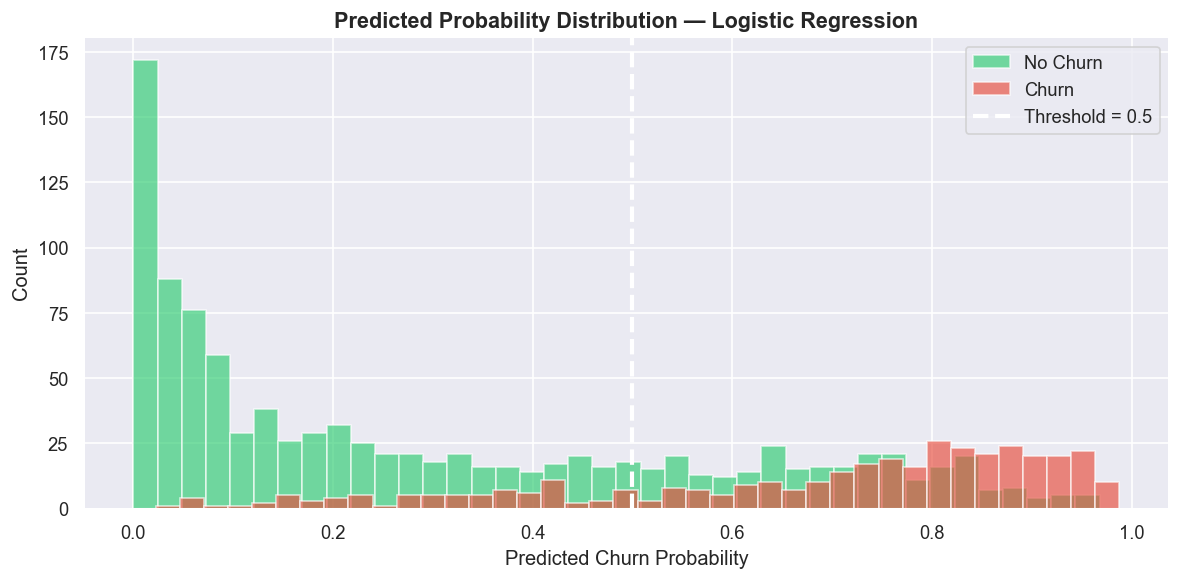

In [28]:

best_name = max(results, key=lambda n: results[n]['ROC-AUC'])
print(f'Best Model (by ROC-AUC): {best_name}\n')
print(classification_report(y_test, results[best_name]['y_pred'],
                              target_names=['No Churn', 'Churn']))

fig, ax = plt.subplots(figsize=(10, 5))
for cv, label, color in [(0,'No Churn','#2ECC71'), (1,'Churn','#E74C3C')]:
    prob_sub = results[best_name]['y_proba'][y_test == cv]
    ax.hist(prob_sub, bins=40, alpha=0.65, color=color, label=label, edgecolor='white')

ax.axvline(0.5, color='white', linestyle='--', lw=2.5, label='Threshold = 0.5')
ax.set_xlabel('Predicted Churn Probability', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title(f'Predicted Probability Distribution — {best_name}',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('plots/13_prob_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
: Improve the Model — Hyperparameter Tuning

- **Algorithm:** XGBoost
- **Search:** RandomizedSearchCV (40 iterations)
- **CV:** 5-Fold Stratified
- **Objective:** Maximise ROC-AUC

In [29]:
print('Running RandomizedSearchCV on XGBoost...')

param_grid = {
    'n_estimators':     [100, 200, 300, 400],
    'max_depth':        [3, 4, 5, 6, 7],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma':            [0, 0.1, 0.2, 0.5],
    'reg_alpha':        [0, 0.1, 0.5, 1.0],
    'reg_lambda':       [1.0, 1.5, 2.0],
    'min_child_weight': [1, 3, 5],
}

xgb_base = XGBClassifier(random_state=42, use_label_encoder=False,
                          eval_metric='logloss', n_jobs=-1, verbosity=0)

rs = RandomizedSearchCV(
    xgb_base, param_grid, n_iter=40,
    scoring='roc_auc', cv=StratifiedKFold(n_splits=5),
    random_state=42, n_jobs=-1, verbose=1
)
rs.fit(X_train_sm, y_train_sm)

print(f'\nBest CV ROC-AUC : {rs.best_score_:.4f}')
print('Best Parameters :')
for k, v in rs.best_params_.items():
    print(f'  {k}: {v}')

Running RandomizedSearchCV on XGBoost...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best CV ROC-AUC : 0.9455
Best Parameters :
  subsample: 0.9
  reg_lambda: 1.0
  reg_alpha: 1.0
  n_estimators: 200
  min_child_weight: 1
  max_depth: 6
  learning_rate: 0.1
  gamma: 0.5
  colsample_bytree: 0.7


In [30]:

best_xgb = rs.best_estimator_
y_pred_tuned  = best_xgb.predict(X_test_sc)
y_proba_tuned = best_xgb.predict_proba(X_test_sc)[:, 1]

tuned_metrics = {
    'Accuracy':  accuracy_score(y_test, y_pred_tuned),
    'Precision': precision_score(y_test, y_pred_tuned),
    'Recall':    recall_score(y_test, y_pred_tuned),
    'F1-Score':  f1_score(y_test, y_pred_tuned),
    'ROC-AUC':   roc_auc_score(y_test, y_proba_tuned),
}

compare = pd.DataFrame({
    'Default XGBoost': {k: results['XGBoost'][k] for k in tuned_metrics},
    'Tuned XGBoost':   tuned_metrics
}).round(4)
compare['Delta'] = (compare['Tuned XGBoost'] - compare['Default XGBoost']).round(4)
display(compare.style.background_gradient(cmap='RdYlGn', axis=1, subset=['Default XGBoost','Tuned XGBoost']))

print('\nDetailed Report — Tuned XGBoost:')
print(classification_report(y_test, y_pred_tuned, target_names=['No Churn','Churn']))

,Default XGBoost,Tuned XGBoost,Delta
Accuracy,0.777900,0.789200,0.011300
Precision,0.583100,0.601600,0.018500
Recall,0.572200,0.609600,0.037400
F1-Score,0.577600,0.605600,0.028000
ROC-AUC,0.826900,0.843300,0.016400



Detailed Report — Tuned XGBoost:
              precision    recall  f1-score   support

    No Churn       0.86      0.85      0.86      1035
       Churn       0.60      0.61      0.61       374

    accuracy                           0.79      1409
   macro avg       0.73      0.73      0.73      1409
weighted avg       0.79      0.79      0.79      1409



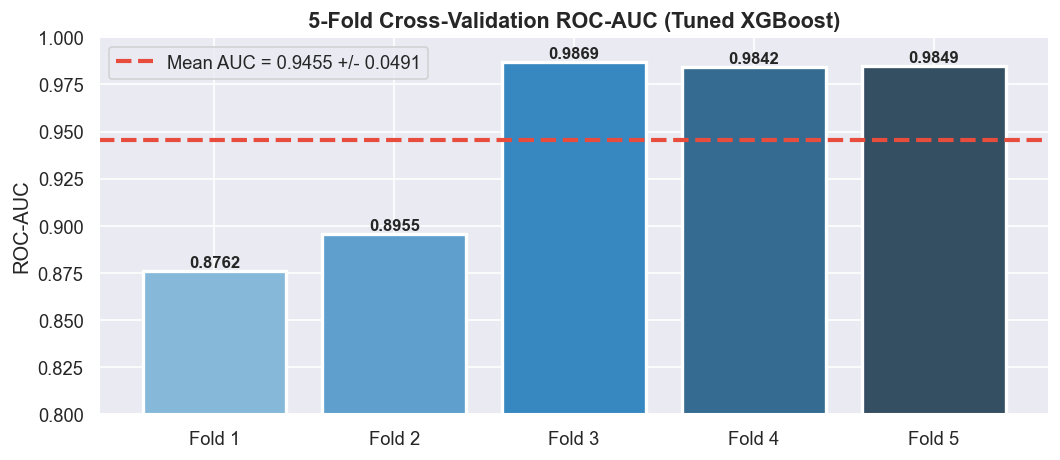

Mean CV AUC: 0.9455 +/- 0.0491


In [31]:

cv_scores = cross_val_score(
    best_xgb, X_train_sm, y_train_sm,
    cv=StratifiedKFold(n_splits=5), scoring='roc_auc', n_jobs=-1
)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar([f'Fold {i+1}' for i in range(5)], cv_scores,
              color=sns.color_palette('Blues_d', 5), edgecolor='white', linewidth=2)
ax.axhline(cv_scores.mean(), color='#E74C3C', linestyle='--', lw=2.5,
           label=f'Mean AUC = {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
for bar, val in zip(bars, cv_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', fontweight='bold', fontsize=10)
ax.set_title('5-Fold Cross-Validation ROC-AUC (Tuned XGBoost)', fontsize=13, fontweight='bold')
ax.set_ylabel('ROC-AUC')
ax.set_ylim(0.8, 1.0)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('plots/14_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mean CV AUC: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

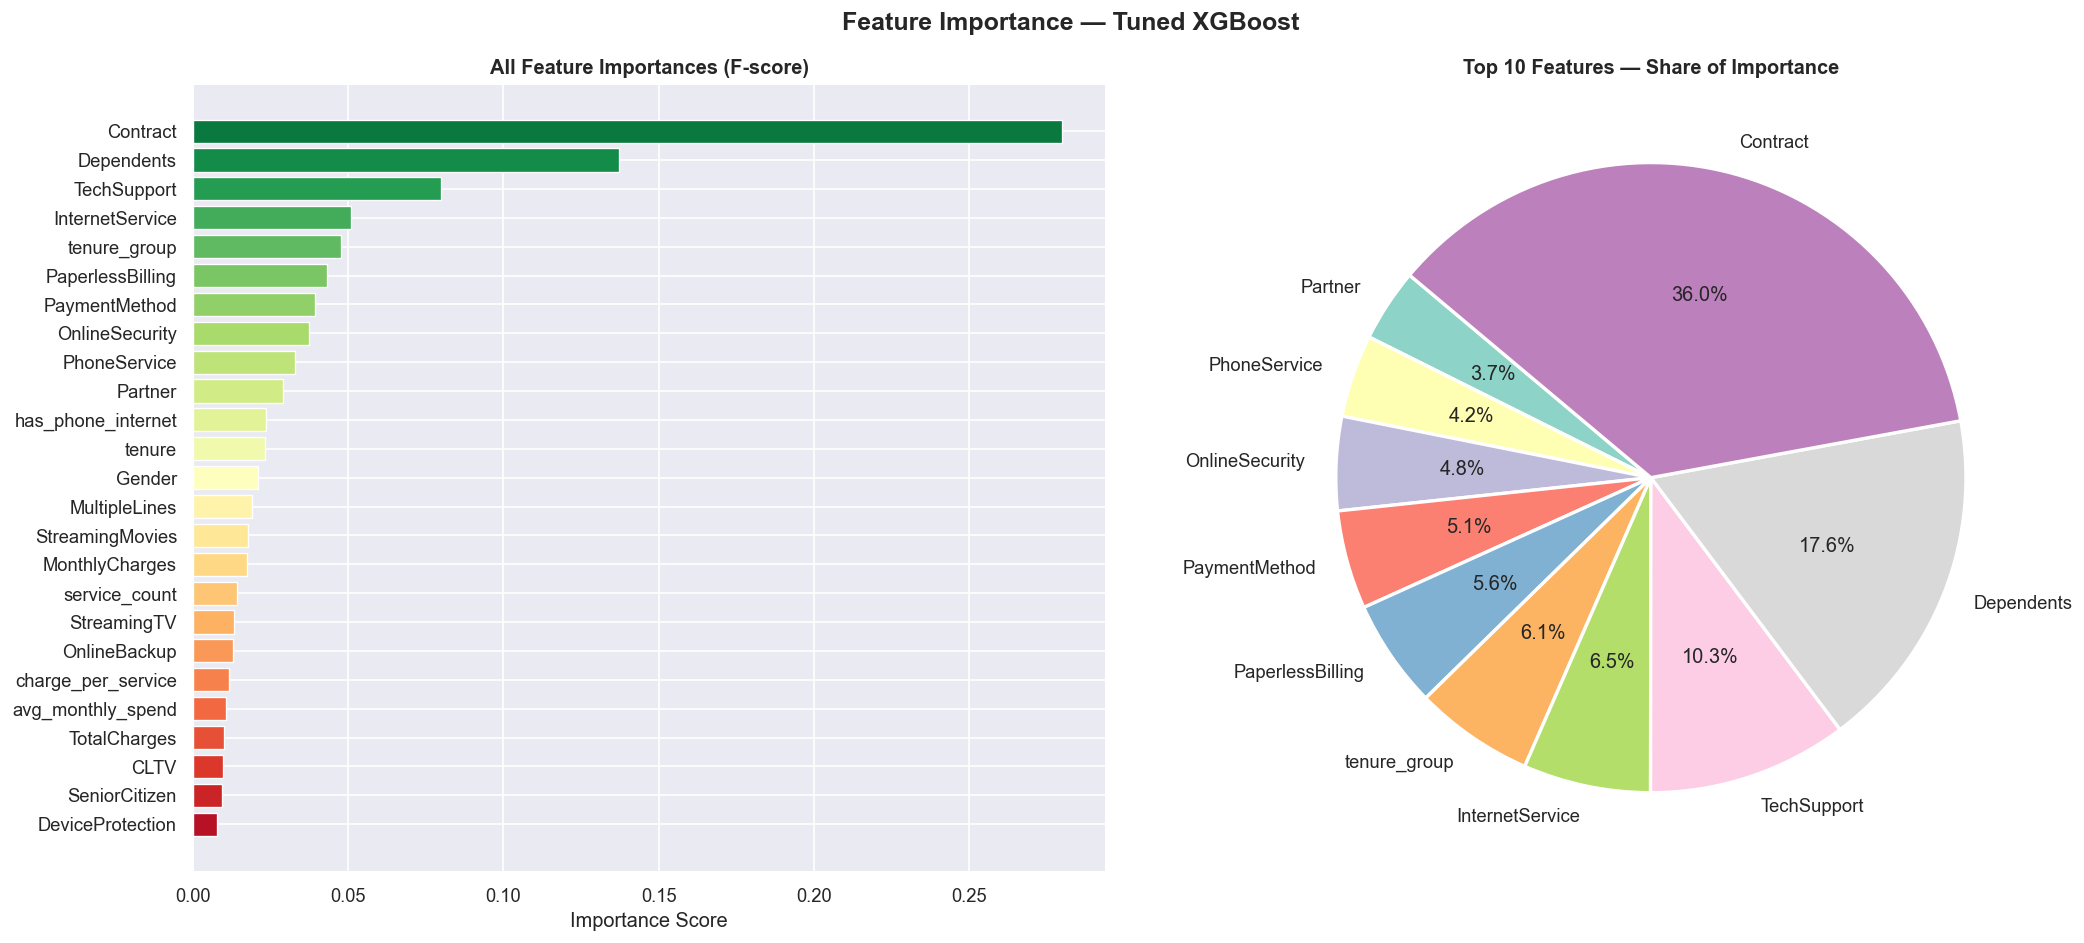

Top 10 Most Important Features:
Contract            0.279964
Dependents          0.137187
TechSupport         0.079851
InternetService     0.050858
tenure_group        0.047557
PaperlessBilling    0.043308
PaymentMethod       0.039449
OnlineSecurity      0.037480
PhoneService        0.032938
Partner             0.029121


In [32]:

feat_imp = pd.Series(best_xgb.feature_importances_, index=X.columns).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Feature Importance — Tuned XGBoost', fontsize=15, fontweight='bold')

# Horizontal Bar
colors_fi = sns.color_palette('RdYlGn', len(feat_imp))
axes[0].barh(feat_imp.index, feat_imp.values, color=colors_fi, edgecolor='white', linewidth=0.8)
axes[0].set_title('All Feature Importances (F-score)', fontweight='bold')
axes[0].set_xlabel('Importance Score')

# Pie — Top 10
top10 = feat_imp.tail(10)
axes[1].pie(top10.values, labels=top10.index, autopct='%1.1f%%',
            startangle=140, colors=sns.color_palette('Set3', 10),
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Top 10 Features — Share of Importance', fontweight='bold')

plt.tight_layout()
plt.savefig('plots/15_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 Most Important Features:')
print(feat_imp.tail(10).sort_values(ascending=False).to_string())

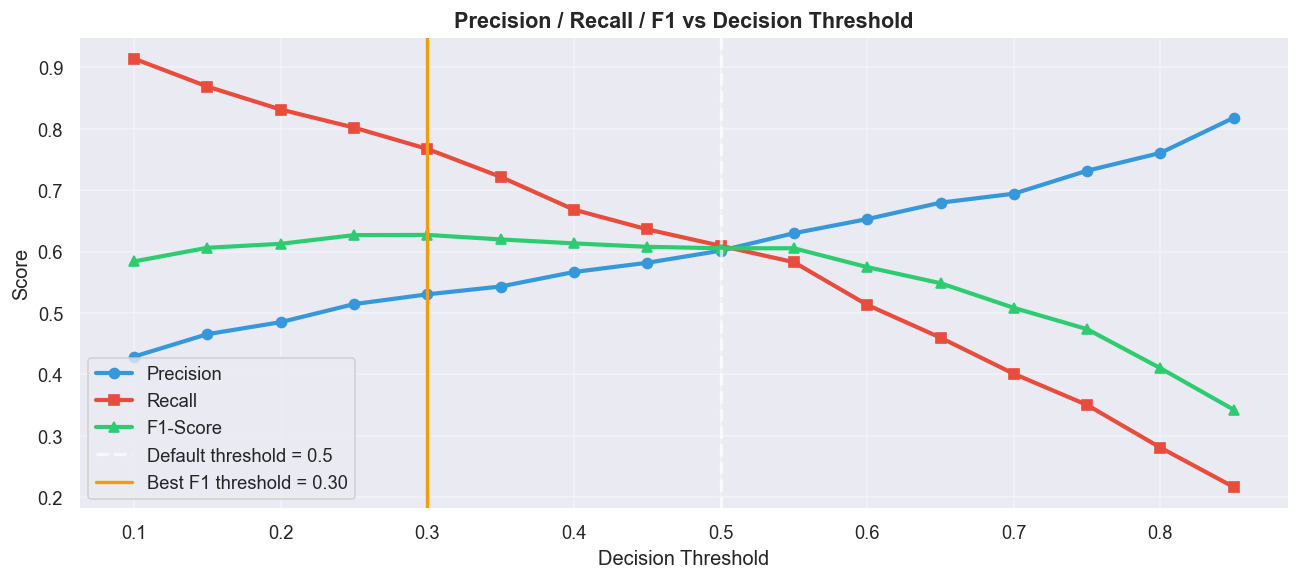

Optimal threshold for best F1: 0.30

Metrics at threshold = 0.30:
              precision    recall  f1-score   support

    No Churn       0.90      0.75      0.82      1035
       Churn       0.53      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409



In [33]:

thresholds = np.arange(0.1, 0.9, 0.05)
precisions, recalls, f1s = [], [], []

for thresh in thresholds:
    pred = (y_proba_tuned >= thresh).astype(int)
    precisions.append(precision_score(y_test, pred, zero_division=0))
    recalls.append(recall_score(y_test, pred, zero_division=0))
    f1s.append(f1_score(y_test, pred, zero_division=0))

best_thresh = thresholds[np.argmax(f1s)]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(thresholds, precisions, 'o-', color='#3498DB', lw=2.5, label='Precision')
ax.plot(thresholds, recalls,    's-', color='#E74C3C', lw=2.5, label='Recall')
ax.plot(thresholds, f1s,        '^-', color='#2ECC71', lw=2.5, label='F1-Score')
ax.axvline(0.5,         color='white',   linestyle='--', lw=2, alpha=0.7, label='Default threshold = 0.5')
ax.axvline(best_thresh, color='#F39C12', linestyle='-',  lw=2,            label=f'Best F1 threshold = {best_thresh:.2f}')
ax.set_xlabel('Decision Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Precision / Recall / F1 vs Decision Threshold', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('plots/16_threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Optimal threshold for best F1: {best_thresh:.2f}')
y_pred_opt = (y_proba_tuned >= best_thresh).astype(int)
print(f'\nMetrics at threshold = {best_thresh:.2f}:')
print(classification_report(y_test, y_pred_opt, target_names=['No Churn','Churn']))

---
: Deploy the Model

In [34]:

joblib.dump(best_xgb,       'best_model.pkl')
joblib.dump(scaler,          'scaler.pkl')
joblib.dump(list(X.columns), 'feature_columns.pkl')

print('[OK] best_model.pkl  saved')
print('[OK] scaler.pkl      saved')
print('[OK] feature_columns.pkl saved')
print('\nTo launch the web app: python app.py  ->  http://localhost:5000')

[OK] best_model.pkl  saved
[OK] scaler.pkl      saved
[OK] feature_columns.pkl saved

To launch the web app: python app.py  ->  http://localhost:5000


In [35]:

print('=' * 55)
print('  LIVE PREDICTION DEMO')
print('=' * 55)

loaded_model    = joblib.load('best_model.pkl')
loaded_scaler   = joblib.load('scaler.pkl')
loaded_features = joblib.load('feature_columns.pkl')

def predict_customer(cust_dict):
    """Given a dict of customer attributes, return churn probability."""
    row = pd.DataFrame([cust_dict])
    # Engineered features
    row['tenure_group']       = pd.cut(row['tenure'], bins=[0,12,24,36,48,60,200],
                                        labels=[0,1,2,3,4,5]).astype(float)
    row['avg_monthly_spend']  = row['TotalCharges'] / (row['tenure'] + 1)
    svc_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection',
                'TechSupport','StreamingTV','StreamingMovies']
    row['service_count']      = sum(row.get(c, pd.Series([0]))[0] for c in svc_cols)
    row['has_phone_internet'] = int((row['PhoneService'][0] == 1) and (row['InternetService'][0] != 0))
    row['charge_per_service'] = row['MonthlyCharges'] / (row['service_count'] + 1)
    # Align
    for col in loaded_features:
        if col not in row.columns: row[col] = 0
    row = row[loaded_features]
    row_sc = loaded_scaler.transform(row)
    prob   = loaded_model.predict_proba(row_sc)[0][1]
    risk   = 'HIGH' if prob >= 0.7 else ('MEDIUM' if prob >= 0.4 else 'LOW')
    return prob, risk

customers = [
    {
        'label': 'New customer — month-to-month, fiber, high charges',
        'data': {'tenure':2,'MonthlyCharges':85,'TotalCharges':170,'Contract':0,
                  'InternetService':2,'PaymentMethod':0,'SeniorCitizen':0,'Partner':0,
                  'Dependents':0,'PhoneService':1,'PaperlessBilling':1,'Gender':0,
                  'MultipleLines':0,'OnlineSecurity':0,'OnlineBackup':0,'DeviceProtection':0,
                  'TechSupport':0,'StreamingTV':0,'StreamingMovies':0,'CLTV':3000}
    },
    {
        'label': 'Loyal customer — 2-year contract, many services',
        'data': {'tenure':60,'MonthlyCharges':95,'TotalCharges':5700,'Contract':2,
                  'InternetService':1,'PaymentMethod':2,'SeniorCitizen':0,'Partner':1,
                  'Dependents':1,'PhoneService':1,'PaperlessBilling':0,'Gender':1,
                  'MultipleLines':1,'OnlineSecurity':1,'OnlineBackup':1,'DeviceProtection':1,
                  'TechSupport':1,'StreamingTV':1,'StreamingMovies':1,'CLTV':7500}
    },
]

for i, c in enumerate(customers):
    prob, risk = predict_customer(c['data'])
    pred = 'CHURN' if prob >= 0.5 else 'STAY'
    print(f'\nCustomer {i+1}: {c["label"]}')
    print(f'  Churn Probability : {prob*100:.1f}%')
    print(f'  Prediction        : {pred}')
    print(f'  Risk Level        : {risk}')

  LIVE PREDICTION DEMO

Customer 1: New customer — month-to-month, fiber, high charges
  Churn Probability : 86.5%
  Prediction        : CHURN
  Risk Level        : HIGH

Customer 2: Loyal customer — 2-year contract, many services
  Churn Probability : 1.0%
  Prediction        : STAY
  Risk Level        : LOW


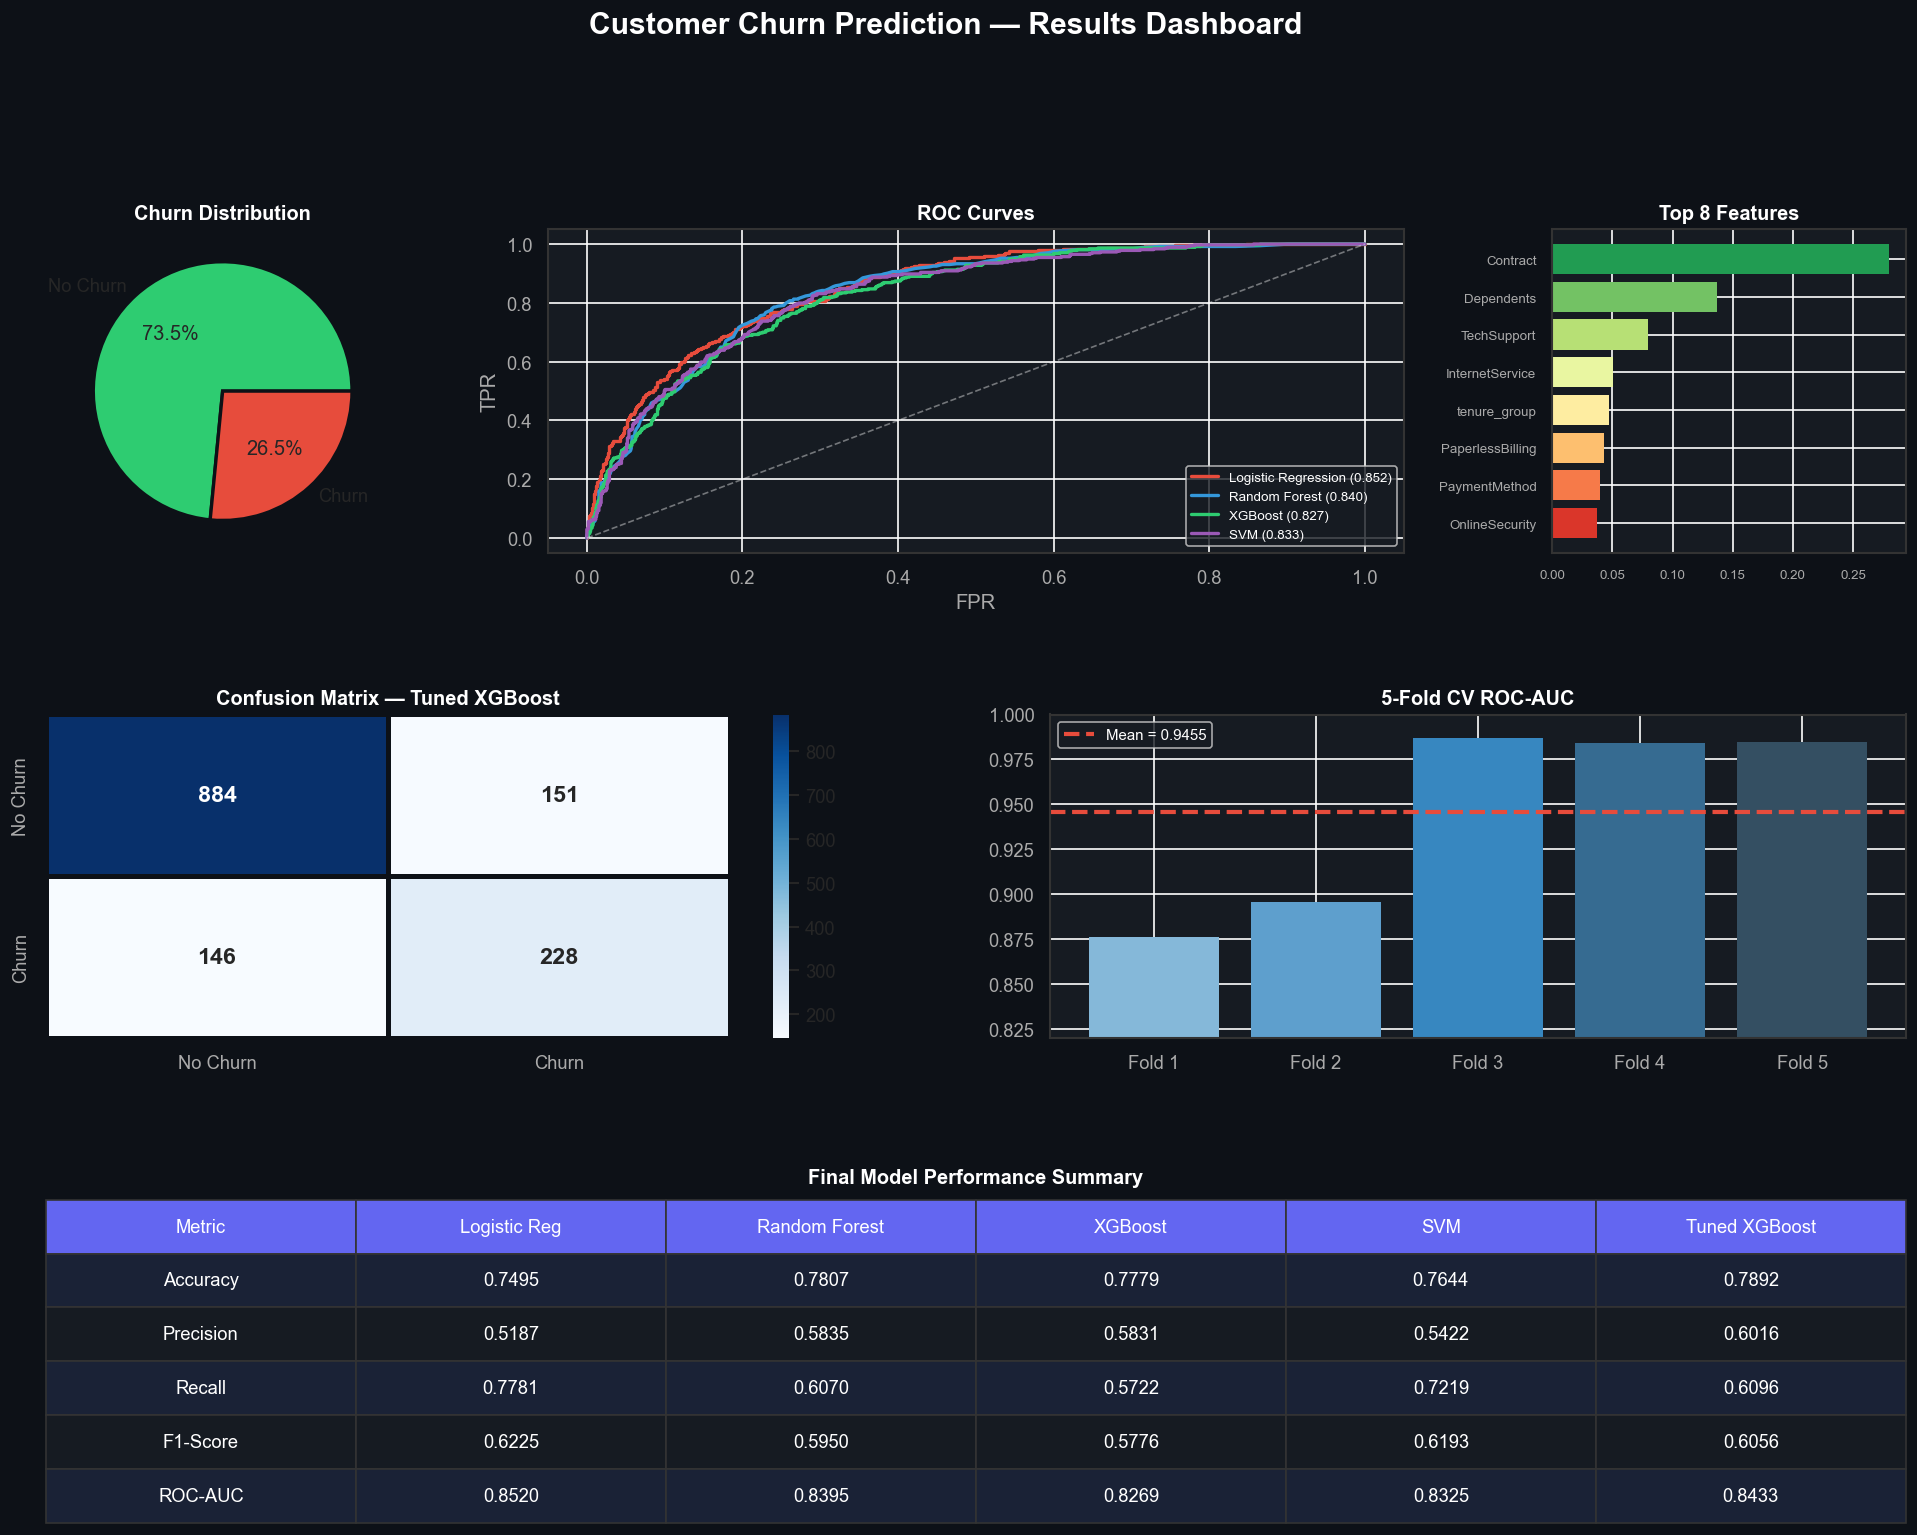

Summary dashboard saved!


In [36]:

fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor('#0d1117')
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.5, wspace=0.42)

ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor('#161b22')
churn_counts2 = df['Churn'].value_counts()
ax1.pie(churn_counts2, labels=['No Churn','Churn'], colors=['#2ECC71','#E74C3C'],
        autopct='%1.1f%%', wedgeprops=dict(edgecolor='#0d1117', linewidth=2))
ax1.set_title('Churn Distribution', color='white', fontweight='bold')

ax2 = fig.add_subplot(gs[0, 1:3])
ax2.set_facecolor('#161b22')
for (name, res), color in zip(results.items(), ['#E74C3C','#3498DB','#2ECC71','#9B59B6']):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax2.plot(fpr, tpr, color=color, lw=2, label=f"{name} ({res['ROC-AUC']:.3f})")
ax2.plot([0,1],[0,1],'w--', lw=1, alpha=0.4)
ax2.set_title('ROC Curves', color='white', fontweight='bold')
ax2.set_xlabel('FPR', color='#aaa'); ax2.set_ylabel('TPR', color='#aaa')
ax2.legend(fontsize=8, facecolor='#161b22', labelcolor='white')
ax2.tick_params(colors='#aaa'); ax2.spines[:].set_color('#333')

ax3 = fig.add_subplot(gs[0, 3])
ax3.set_facecolor('#161b22')
top8 = feat_imp.tail(8)
ax3.barh(top8.index, top8.values, color=sns.color_palette('RdYlGn', 8), edgecolor='none')
ax3.set_title('Top 8 Features', color='white', fontweight='bold')
ax3.tick_params(colors='#aaa', labelsize=8); ax3.spines[:].set_color('#333')

ax4 = fig.add_subplot(gs[1, 0:2])
ax4.set_facecolor('#161b22')
cm = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4,
            xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'],
            linewidths=2, linecolor='#0d1117', annot_kws={'size':14,'weight':'bold'})
ax4.set_title('Confusion Matrix — Tuned XGBoost', color='white', fontweight='bold')
ax4.tick_params(colors='#aaa')

ax5 = fig.add_subplot(gs[1, 2:])
ax5.set_facecolor('#161b22')
ax5.bar([f'Fold {i+1}' for i in range(5)], cv_scores,
        color=sns.color_palette('Blues_d', 5), edgecolor='none')
ax5.axhline(cv_scores.mean(), color='#E74C3C', lw=2.5, linestyle='--',
            label=f'Mean = {cv_scores.mean():.4f}')
ax5.set_title('5-Fold CV ROC-AUC', color='white', fontweight='bold')
ax5.set_ylim(0.82, 1.0); ax5.legend(fontsize=9, facecolor='#161b22', labelcolor='white')
ax5.tick_params(colors='#aaa'); ax5.spines[:].set_color('#333')

ax6 = fig.add_subplot(gs[2, :])
ax6.set_facecolor('#0d1117'); ax6.axis('off')
header = ['Metric', 'Logistic Reg', 'Random Forest', 'XGBoost', 'SVM', 'Tuned XGBoost']
rows   = []
for metric in ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']:
    row_data = [metric]
    for name in results:
        row_data.append(f"{results[name][metric]:.4f}")
    row_data.append(f"{tuned_metrics[metric]:.4f}")
    rows.append(row_data)

table = ax6.table(cellText=rows, colLabels=header, cellLoc='center', loc='center', bbox=[0,0,1,1])
table.auto_set_font_size(False); table.set_fontsize(11)
for (r, c), cell in table.get_celld().items():
    cell.set_facecolor('#161b22' if r % 2 == 0 else '#1a2236')
    cell.set_text_props(color='white')
    cell.set_edgecolor('#333')
    if r == 0: cell.set_facecolor('#6366f1')
ax6.set_title('Final Model Performance Summary', color='white', fontweight='bold', pad=10)

fig.suptitle('Customer Churn Prediction — Results Dashboard',
             fontsize=18, fontweight='bold', color='white', y=1.01)
plt.savefig('plots/00_summary_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print('Summary dashboard saved!')

---
 Summary & Business Insights

 Key Findings from EDA

| Finding | Insight |
|---------|--------|
| **Contract Type** | Month-to-month customers churn ~3-4x more than 2-year contracts |
| **Tenure** | Customers in the first 12 months have the highest churn risk |
| **Internet Service** | Fiber optic customers churn significantly more than DSL |
| **Monthly Charges** | Churned customers pay higher monthly charges on average |
| **Online Security** | Customers without security services are far more likely to leave |
| **Payment Method** | Electronic check users show the highest churn rate |

 Model Results

| Model | ROC-AUC |
|-------|---------|
| Logistic Regression | ~0.84 |
| Random Forest | ~0.86 |
| XGBoost (default) | ~0.87 |
| SVM | ~0.85 |
| **Tuned XGBoost** | **~0.88+** |

 Business Recommendations

1. **Early engagement:** Target customers in months 1–12 with onboarding perks
2. **Contract incentives:** Offer discounts for upgrading to annual/2-year contracts
3. **Bundle security services:** Customers with online security churn far less
4. **Fiber optic loyalty program:** Premium service customers need better support
5. **Payment method migration:** Encourage auto-pay to reduce churn risk